In [62]:
# 1) Imports and configuration
import os
import time
import random
import numpy as np
import torch
from torch.utils.data import IterableDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"
samples_to_load = 400
seed = 32
train_frac = 0.8
batch_size = 75
num_steps = 1000
log_iter = 10
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9
sample_id = 5
num_samples_to_evaluate = 10

resume_path = ""
resume_strict = True
save_best = True
save_last = True

# RNO preprocessing hyperparameters
sub = 1
T = 16
n_intervals = 5
train_up_to_tipping_point = False
tipping_data_split_prop = 0.67
debug_preprocessing_shapes = True


This notebook is the `sin_embed` variant. It is self-contained.


In [63]:
# 2) Reproducibility and device
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required but not available.")
device = torch.device("cuda")
print(f"Using device: {device}")


Using device: cuda


In [64]:
# 3) Data loading and RNO preprocessing
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found: {data_path}")

dataset = np.load(data_path)
solutions = torch.from_numpy(dataset["solutions"][:samples_to_load]).float()
controls = torch.from_numpy(dataset["controls"][:samples_to_load]).float()
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1).float()
dt = float(dataset["dt"])

print(f"Loaded {samples_to_load}/{dataset['solutions'].shape[0]} samples:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"controls: {tuple(controls.shape)}")
print(f"x: {tuple(x_cord.shape)}")
print(f"dt: {dt}")

Loaded 400/3000 samples:
solutions: (400, 401, 100)
controls: (400, 400, 4)
x: (100, 1)
dt: 0.001


In [65]:
def round_down(num, divisor):
    return num - (num % divisor)


def chunk_time_axis(arr, chunk_size):
    # arr shape: (ntraj, nt, nfeat) -> (ntraj, n_chunks, chunk_size, nfeat)
    chunks = torch.split(arr, chunk_size, dim=1)
    return torch.stack(chunks, dim=1)

In [66]:
# 1) Align solution/control time lengths and crop to multiple of T
ntraj = min(solutions.shape[0], controls.shape[0])
nt_shared = min(solutions.shape[1] - 1, controls.shape[1])
nt_usable = round_down(nt_shared, T)

solutions = solutions[:ntraj, :nt_usable, :]
controls = controls[:ntraj, :nt_usable, :]

# 2) Optional spatial subsampling on solution/grid only
solutions = solutions[:, :, ::sub]
x_cord = x_cord[::sub]

# 3) Optional pre-tipping crop
if train_up_to_tipping_point:
    tipping_idx = round_down(int(tipping_data_split_prop * solutions.shape[1]), T)
    solutions = solutions[:, :tipping_idx, :]
    controls = controls[:, :tipping_idx, :]

ntraj, nt, nx = solutions.shape
nf = controls.shape[-1]
n_chunks = nt // T

print(f"After preprocessing:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"controls: {tuple(controls.shape)}")
print(f"x: {tuple(x_cord.shape)}")
print(f"ntraj: {ntraj}, nt: {nt}, nx: {nx}, nf: {nf}, n_chunks: {n_chunks}")


After preprocessing:
solutions: (400, 400, 100)
controls: (400, 400, 4)
x: (100, 1)
ntraj: 400, nt: 400, nx: 100, nf: 4, n_chunks: 25


Train/test split by trajectory (same strategy as ks/RNO_KS.py)

In [67]:
# 4) Train/test split by trajectory (same strategy as ks/RNO_KS.py)
n_train_traj = int(train_frac * ntraj)
n_test_traj = ntraj - n_train_traj

sol_train = solutions[:n_train_traj]
sol_test = solutions[n_train_traj:]
ctrl_train = controls[:n_train_traj]
ctrl_test = controls[n_train_traj:]

In [68]:
print(f"Before chunking:")
print(f"sol_train: {tuple(sol_train.shape)}")
print(f"ctrl_train: {tuple(ctrl_train.shape)}")
print(f"sol_test: {tuple(sol_test.shape)}")
print(f"ctrl_test: {tuple(ctrl_test.shape)}")

Before chunking:
sol_train: (320, 400, 100)
ctrl_train: (320, 400, 4)
sol_test: (80, 400, 100)
ctrl_test: (80, 400, 4)


Chunk with T=16: (400 timesteps)

Raw time: 400
Chunk size: T=16
Number of chunks per trajectory: 400/16 = 25

U_chunks: (B, 25, 16, 100, 1)
F_chunks: (B, 25, 16, 4)

In [69]:
# 5) Chunk both streams (keep state and control separate)
sol_train_chunks = chunk_time_axis(sol_train, T).unsqueeze(
    -1
)  # (n_tr, n_chunks, T, nx, 1)
sol_test_chunks = chunk_time_axis(sol_test, T).unsqueeze(
    -1
)  # (n_te, n_chunks, T, nx, 1)

ctrl_train_chunks = chunk_time_axis(ctrl_train, T).unsqueeze(
    -1
)  # (n_tr, n_chunks, T, nf, 1)
ctrl_test_chunks = chunk_time_axis(ctrl_test, T).unsqueeze(
    -1
)  # (n_te, n_chunks, T, nf, 1)

print("After chunking:")
print(f"sol_train_chunks: {tuple(sol_train_chunks.shape)}")
print(f"ctrl_train_chunks: {tuple(ctrl_train_chunks.shape)}")
print(f"sol_test_chunks: {tuple(sol_test_chunks.shape)}")
print(f"ctrl_test_chunks: {tuple(ctrl_test_chunks.shape)}")


After chunking:
sol_train_chunks: (320, 25, 16, 100, 1)
ctrl_train_chunks: (320, 25, 16, 4, 1)
sol_test_chunks: (80, 25, 16, 100, 1)
ctrl_test_chunks: (80, 25, 16, 4, 1)


Build training samples with a sliding window of `n_intervals=5`:

Input uses 5 consecutive chunks: `[i, i+1, i+2, i+3, i+4]`
Target is next chunk: `[i+5]`

So for the model input:

* `timesteps = 5` (history length in chunk units)
* `spatial_dims = (16, 100)` (chunk-internal time, space)
* That gives input like `(batch, 5, channels, 16, 100)` after permute.

Mini picture for one trajectory:

- chunks: `c0 c1 c2 c3 c4 c5 c6 ... c24`
- sample 1: `input=c0..c4`, `target=c5`
- sample 2: `input=c1..c5`, `target=c6`
etc.

In [70]:
def build_windows(sol_chunks, ctrl_chunks, n_intervals_inner):
    x_state, x_ctrl, y_state = [], [], []
    for traj_sol, traj_ctrl in zip(sol_chunks, ctrl_chunks):
        for i in range(sol_chunks.shape[1] - n_intervals_inner - 1):
            x_state.append(traj_sol[i : i + n_intervals_inner])
            x_ctrl.append(traj_ctrl[i : i + n_intervals_inner])
            y_state.append(traj_sol[i + n_intervals_inner])

    x_state = torch.stack(x_state, dim=0)  # (N, n_intervals, T, nx, 1)
    x_ctrl = torch.stack(x_ctrl, dim=0)  # (N, n_intervals, T, nf, 1)
    y_state = torch.stack(y_state, dim=0)  # (N, T, nx, 1)

    x_state = x_state.permute(0, 1, 4, 2, 3).contiguous()  # (N, n_intervals, 1, T, nx)
    x_ctrl = x_ctrl.permute(0, 1, 4, 2, 3).contiguous()  # (N, n_intervals, 1, T, nf)
    y_state = y_state.permute(0, 3, 1, 2).contiguous()  # (N, 1, T, nx)
    return x_state, x_ctrl, y_state


x_train_state, x_train_ctrl, y_train = build_windows(
    sol_train_chunks, ctrl_train_chunks, n_intervals
)
x_test_state, x_test_ctrl, y_test = build_windows(
    sol_test_chunks, ctrl_test_chunks, n_intervals
)

if debug_preprocessing_shapes:
    print("=== RNO preprocessing debug ===")
    print(f"ntraj={ntraj}, nt={nt}, nx={nx}, nf={nf}, n_chunks={n_chunks}")
    print(f"n_train_traj={n_train_traj}, n_test_traj={n_test_traj}")
    print(f"sol_train_chunks: {tuple(sol_train_chunks.shape)}")
    print(f"ctrl_train_chunks: {tuple(ctrl_train_chunks.shape)}")
    print(f"x_train_state: {tuple(x_train_state.shape)}")
    print(f"x_train_ctrl: {tuple(x_train_ctrl.shape)}")
    print(f"y_train: {tuple(y_train.shape)}")
    print(f"x_test_state: {tuple(x_test_state.shape)}")
    print(f"x_test_ctrl: {tuple(x_test_ctrl.shape)}")
    print(f"y_test: {tuple(y_test.shape)}")
    print("=== End preprocessing debug ===")


=== RNO preprocessing debug ===
ntraj=400, nt=400, nx=100, nf=4, n_chunks=25
n_train_traj=320, n_test_traj=80
sol_train_chunks: (320, 25, 16, 100, 1)
ctrl_train_chunks: (320, 25, 16, 4, 1)
x_train_state: (6080, 5, 1, 16, 100)
x_train_ctrl: (6080, 5, 1, 16, 4)
y_train: (6080, 1, 16, 100)
x_test_state: (1520, 5, 1, 16, 100)
x_test_ctrl: (1520, 5, 1, 16, 4)
y_test: (1520, 1, 16, 100)
=== End preprocessing debug ===


In [71]:
# Dataloaders for RNO training (state, control, target_state)
train_loader = DataLoader(
    torch.utils.data.TensorDataset(x_train_state, x_train_ctrl, y_train),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)
test_loader = DataLoader(
    torch.utils.data.TensorDataset(x_test_state, x_test_ctrl, y_test),
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
)

xb_state, xb_ctrl, yb = next(iter(train_loader))
print(f"train batch state: {tuple(xb_state.shape)}")
print(f"train batch control: {tuple(xb_ctrl.shape)}")
print(f"train batch target: {tuple(yb.shape)}")


train batch state: (75, 5, 1, 16, 100)
train batch control: (75, 5, 1, 16, 4)
train batch target: (75, 1, 16, 100)


In [72]:
# 4) RNO utilities
import operator
from functools import reduce
from tqdm.auto import tqdm


class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        assert d > 0 and p > 0
        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def rel(self, x, y):
        num_examples = x.size()[0]
        diff_norms = torch.norm(
            x.reshape(num_examples, -1) - y.reshape(num_examples, -1), self.p, 1
        )
        y_norms = torch.norm(y.reshape(num_examples, -1), self.p, 1)
        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms / y_norms)
            return torch.sum(diff_norms / y_norms)
        return diff_norms / y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul, list(p.size()), 1)
    return c


From documentation: Input tensor `x_train` with shape `(batch, timesteps, in_channels, *spatial_dims)`, where `len(spatial_dims) == self.n_dim`. The channel dimension MUST be at index 2 and the time dimension MUST be at index 1.

Source: https://neuraloperator.github.io/dev/modules/generated/neuralop.models.RNO.html#neuralop.models.RNO

## Audit: current behavior

_Note: This is the sin-embed-strategy notebook._

### Strategy 1 currently in notebook (before refactor)
- State chunks are built as `(n_tr, n_chunks, 16, 100, 1)`.
- Controls are chunked as `(n_tr, n_chunks, 16, 4)`, then broadcast over the `x` axis with `unsqueeze(3).expand(-1, -1, -1, nx, -1)` to `(n_tr, n_chunks, 16, 100, 4)`.
- State and control are concatenated channel-last with `torch.cat([x_sol, x_ctrl], dim=-1)` to form `(N, n_intervals, 16, 100, 5)`.

### Exact model input and channels
- `in_channels` is set from `x_train.shape[-1]`, so the model is configured with `in_channels=5` (expected), `out_channels=1`.
- Batches are passed to `model.predict` as `x_in = x_batch.permute(0, 1, 4, 2, 3)`.
- Exact forward input shape is `(B, n_intervals, 5, 16, 100)`.

### Training target and loss behavior
- Target is only the next chunk: `y_sol[i + n_intervals]` with shape `(B, 16, 100, 1)`.
- Training uses `model.predict(x_in, num_steps=1)[:, -1]`, then permutes to `(B, 16, 100, 1)`.
- Loss is one-step relative L2 (`LpLoss`) over the full chunk field, not sequence loss over multiple future steps.
- This is teacher-forced history input (fixed ground-truth context window), not free-run multi-step autoregressive training.

### Existing rollout path
- Rollout comparison is in cells 18-19 via `evaluate_rollout_steps`.
- It uses `model.predict(x_in, num_steps=h)` from a fixed input window.
- For `h > 1`, future controls are not injected at each predicted step; rollout proceeds from predicted states only.


In [73]:
# 5a) Sin-embed imports + embedding probe Example adapted from Neural Operator docs:
# https://neuraloperator.github.io/dev/auto_examples/layers/plot_sinusoidal_embeddings.html

from neuralop.models import RNO
from neuralop.layers.embeddings import SinusoidalEmbedding

try:
    from rno_functions import ControlLifterSin, RNOControlARSinEmbed
except ModuleNotFoundError:
    from heat.rno_functions import ControlLifterSin, RNOControlARSinEmbed

model_input_mode = "sin_embed"
control_dim = int(x_train_ctrl.shape[-1])

probe_embedding = SinusoidalEmbedding(
    in_channels=control_dim,
    num_frequencies=4,
    embedding_type="transformer",  # options: "nerf", "transformer"
    max_positions=10000,
)
probe_x = torch.randn(2, 7, control_dim)
probe_y = probe_embedding(probe_x)
print("SinusoidalEmbedding probe:", tuple(probe_x.shape), "->", tuple(probe_y.shape))
print("Probe out_channels:", probe_embedding.out_channels)


SinusoidalEmbedding probe: (2, 7, 4) -> (2, 7, 32)
Probe out_channels: 32


In [76]:
print(int(x_train_ctrl.shape[-1]))

4


In [74]:
# 5b) Sin-embed input builder


def build_rno_input(x_state, x_ctrl):
    # x_state: (B, T_hist, 1, 16, 100), x_ctrl: (B, T_hist, 1, 16, control_dim)
    return RNOControlARSinEmbed.build_rno_input(x_state, x_ctrl, control_lifter)


In [80]:
# 5c) Sin-embed model + optimizer setup
modes1 = 20
modes2 = 20
width = 28
n_layers = 3
domain_padding = [0.1, 0]

in_channels = 2
num_frequencies = 14
# ControlLifterSin is a plain callable; .to(device) is forwarded to its internal embedding module.
control_lifter = ControlLifterSin(
    control_dim=int(x_train_ctrl.shape[-1]),
    embed_dim=100,
    num_frequencies=num_frequencies,
    embedding_type="transformer",
    max_positions=10000,
)
out_channels = 1
learning_rate = lr
weight_decay = 1e-4
scheduler_step = 50
scheduler_gamma = 0.5
epochs = 25
save_weights = True

model = RNO(
    n_modes=(modes1, modes2),
    hidden_channels=width,
    in_channels=in_channels,
    out_channels=out_channels,
    n_layers=n_layers,
    domain_padding=domain_padding,
).to(device)

ar_model = RNOControlARSinEmbed(rno=model, control_lifter=control_lifter).to(device)

print(f"model_input_mode={model_input_mode}")
print(f"control_dim={control_dim}")
print(f"in_channels={in_channels}, out_channels={out_channels}")
print("Model parameters:", count_params(model))

opt_params = list(model.parameters())
optimizer = torch.optim.Adam(opt_params, lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=scheduler_step, gamma=scheduler_gamma
)
lploss = LpLoss(size_average=False)


model_input_mode=sin_embed
control_dim=4
in_channels=2, out_channels=1
Model parameters: 3138197


In [81]:
# 6) Shape sanity (non-invasive debug cell)
model.eval()

with torch.no_grad():
    xb_state, xb_ctrl, yb = next(iter(train_loader))
    xb_state = xb_state.to(device).float()  # (B, T_hist, 1, 16, 100)
    xb_ctrl = xb_ctrl.to(device).float()  # (B, T_hist, 1, 16, n_ctrl)
    yb = yb.to(device).float()  # (B, 1, 16, 100)

    x_in_dbg = build_rno_input(
        xb_state,
        xb_ctrl,
    )  # (B, T_hist, C_in, 16, 100)
    # y_pred_dbg = model.predict(x_in_dbg, num_steps=1)[:, -1]  # (B, 1, 16, 100)
    y_pred_dbg = model.predict(x_in_dbg, num_steps=1)  # (B, 1, 16, 100)

    print("dataset batch output:")
    print("  state:", tuple(xb_state.shape))
    print("  control:", tuple(xb_ctrl.shape))
    print("  target:", tuple(yb.shape))
    print("model input tensor:", tuple(x_in_dbg.shape))
    print("model output tensor:", tuple(y_pred_dbg.shape))
    print("loss inputs:", tuple(y_pred_dbg.shape), tuple(yb.shape))

model.train()


dataset batch output:
  state: (75, 5, 1, 16, 100)
  control: (75, 5, 1, 16, 4)
  target: (75, 1, 16, 100)
model input tensor: (75, 5, 2, 16, 100)
model output tensor: (75, 1, 1, 16, 100)
loss inputs: (75, 1, 1, 16, 100) (75, 1, 16, 100)


RNO(
  (domain_padding): DomainPadding()
  (positional_embedding): GridEmbeddingND()
  (layers): ModuleList(
    (0-2): 3 x RNOBlock(
      (cell): RNOCell(
        (input_gates): ModuleList(
          (0-2): 3 x FNOBlocks(
            (convs): ModuleList(
              (0): SpectralConv(
                (weight): DenseTensor(shape=torch.Size([28, 28, 20, 11]), rank=None)
              )
            )
            (fno_skips): ModuleList(
              (0): Flattened1dConv(
                (conv): Conv1d(28, 28, kernel_size=(1,), stride=(1,), bias=False)
              )
            )
            (channel_mlp): ModuleList(
              (0): ChannelMLP(
                (fcs): ModuleList(
                  (0): Conv1d(28, 14, kernel_size=(1,), stride=(1,))
                  (1): Conv1d(14, 28, kernel_size=(1,), stride=(1,))
                )
              )
            )
            (channel_mlp_skips): ModuleList(
              (0): SoftGating()
            )
          )
        )
      

In [51]:
# 7) RNO training loop (control-aware input construction)
# Matched to run_one_step_baseline_training semantics:
# - deterministic train shuffle order
# - drop_last=True (train), drop_last=False (test)
# - per-epoch metrics normalized by processed sample counts

num_train_samples = x_train_state.shape[0]
num_test_samples = x_test_state.shape[0]
training_loss_history = []
test_loss_history = []

# Deterministic train shuffle order for fairness.
g = torch.Generator(device="cpu")
g.manual_seed(seed)
train_loader_local = DataLoader(
    torch.utils.data.TensorDataset(x_train_state, x_train_ctrl, y_train),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    generator=g,
)
test_loader_local = DataLoader(
    torch.utils.data.TensorDataset(x_test_state, x_test_ctrl, y_test),
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

print("Begin RNO training:")
debug_shapes_printed = False

for ep in range(1, epochs + 1):
    t_start = time.time()
    model.train()

    train_l2_sum = 0.0
    train_count = 0

    for x_state_batch, x_ctrl_batch, y_batch in tqdm(train_loader_local, leave=False):
        x_state_batch = x_state_batch.to(device).float()  # (B, T_hist, 1, 16, 100)
        x_ctrl_batch = x_ctrl_batch.to(device).float()  # (B, T_hist, 1, 16, n_ctrl)
        y_batch = y_batch.to(device).float()  # (B, 1, 16, 100)

        x_in = build_rno_input(
            x_state_batch,
            x_ctrl_batch,
        )  # (B, T_hist, C_in, 16, 100)
        pred_rollout = model.predict(x_in, num_steps=1)  # (B, 1, 1, 16, 100)
        out_window = pred_rollout[:, -1]  # (B, 1, 16, 100)

        if not debug_shapes_printed:
            print("x_in shape:", tuple(x_in.shape))
            print("pred_rollout shape:", tuple(pred_rollout.shape))
            print("pred_rollout[:, -1] shape:", tuple(pred_rollout[:, -1].shape))
            print("y_batch shape:", tuple(y_batch.shape))
            debug_shapes_printed = True

        loss = lploss(out_window, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_l2_sum += loss.item()
        train_count += x_state_batch.size(0)

    model.eval()

    test_rel_sum = 0.0
    test_count = 0
    with torch.no_grad():
        for x_state_batch, x_ctrl_batch, y_batch in test_loader_local:
            x_state_batch = x_state_batch.to(device).float()
            x_ctrl_batch = x_ctrl_batch.to(device).float()
            y_batch = y_batch.to(device).float()

            x_in = build_rno_input(
                x_state_batch,
                x_ctrl_batch,
            )
            pred_rollout = model.predict(x_in, num_steps=1)
            out_window = pred_rollout[:, -1]
            test_rel_sum += lploss(out_window, y_batch).item()
            test_count += x_state_batch.size(0)

    train_l2 = train_l2_sum / max(train_count, 1)
    test_l2 = test_rel_sum / max(test_count, 1)

    training_loss_history.append(train_l2)
    test_loss_history.append(test_l2)

    runtime = time.time() - t_start
    print(
        f"Epoch {ep:03d}/{epochs} | Train L2={train_l2:.4e} | Test L2={test_l2:.4e} | runtime={runtime:.2f}s"
    )


Begin RNO training:


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 001/25 | time=10.35s | train_l2=1.1716e+00 | test_l2=9.1957e-01


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 002/25 | time=5.42s | train_l2=8.4661e-01 | test_l2=8.3924e-01


...

Epoch 023/25 | time=5.53s | train_l2=6.8161e-01 | test_l2=8.3237e-01


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 024/25 | time=5.50s | train_l2=6.8289e-01 | test_l2=8.3238e-01


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 025/25 | time=5.49s | train_l2=6.8159e-01 | test_l2=8.3240e-01


In [52]:
# 8) Save model weights
if save_weights:
    result_dir = os.path.join(os.getcwd(), f"result_rno_{seed}_sin_embed")
    os.makedirs(result_dir, exist_ok=True)
    model_path = os.path.join(result_dir, "rno_model_last.pt")
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epochs": epochs,
            "seed": seed,
            "config": {
                "modes1": modes1,
                "modes2": modes2,
                "width": width,
                "model_input_mode": model_input_mode,
                "in_channels": in_channels,
                "out_channels": out_channels,
                "n_layers": n_layers,
                "domain_padding": domain_padding,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "scheduler_step": scheduler_step,
                "scheduler_gamma": scheduler_gamma,
                "T": T,
                "n_intervals": n_intervals,
                "sub": sub,
            },
            "train_loss_history": training_loss_history,
            "test_loss_history": test_loss_history,
        },
        model_path,
    )
    print(f"Saved weights to: {model_path}")
else:
    print("save_weights=False, skipping model save.")


Saved weights to: /home/pk222/projects/tipping-point-forecast/heat/result_rno_32_sin_embed/rno_model_last.pt


In [53]:
# 9) Control-aware rollout example (uses exogenous controls at each step)
model.eval()

with torch.no_grad():
    xb_state, xb_ctrl, _ = next(iter(test_loader))
    xb_state = xb_state.to(device).float()  # (B, T_hist, 1, 16, 100)
    xb_ctrl = xb_ctrl.to(device).float()  # (B, T_hist, 1, 16, n_ctrl)

    u0 = xb_state[:, 0]  # (B, 1, 16, 100)
    ctrl_seq = xb_ctrl[:, :2]  # (B, 2, 1, 16, n_ctrl)
    rollout_pred = ar_model.rollout(u0=u0, ctrl_seq=ctrl_seq, steps=2)

    print("u0:", tuple(u0.shape))
    print("ctrl_seq:", tuple(ctrl_seq.shape))
    print("rollout_pred:", tuple(rollout_pred.shape))


u0: (75, 1, 16, 100)
ctrl_seq: (75, 2, 1, 16, 4)
rollout_pred: (75, 3, 1, 16, 100)


In [54]:
# 10) Unit-test-like shape checks + tiny numerical smoke test (1 batch)
model.eval()

xb_state, xb_ctrl, _ = next(iter(train_loader))
xb_state = xb_state.to(device).float()  # (B, T_hist, 1, 16, 100)
xb_ctrl = xb_ctrl.to(device).float()  # (B, T_hist, 1, 16, n_ctrl)

B, T_hist = xb_state.shape[0], xb_state.shape[1]
n_ctrl = xb_ctrl.shape[-1]

x_in_sin = build_rno_input(
    xb_state,
    xb_ctrl,
)  # (B, T_hist, 2, 16, 100)
assert x_in_sin.shape == (B, T_hist, 2, 16, 100), x_in_sin.shape

u0_hist = xb_state[:, 0]  # (B, 1, 16, 100)
with torch.no_grad():
    y_pred_roll = ar_model.rollout(
        u0=u0_hist,
        ctrl_seq=xb_ctrl[:, :T_hist],
        steps=T_hist,
    )  # (B, T_hist+1, 1, 16, 100)
    y_pred = y_pred_roll[:, 1:]  # (B, T_hist, 1, 16, 100)
assert y_pred.shape == (B, T_hist, 1, 16, 100), y_pred.shape

u0 = xb_state[:, 0]  # (B, 1, 16, 100)
ctrl_two = xb_ctrl[:, :2]  # (B, 2, 1, 16, n_ctrl)
with torch.no_grad():
    rollout_out = ar_model.rollout(u0=u0, ctrl_seq=ctrl_two, steps=2)
assert rollout_out.shape == (B, 3, 1, 16, 100), rollout_out.shape

with torch.no_grad():
    rollout_tf = ar_model.rollout(
        u0=u0,
        ctrl_seq=ctrl_two,
        steps=2,
        teacher_forcing_states=xb_state[:, :2],
        use_teacher_forcing=True,
    )
assert rollout_tf.shape == (B, 3, 1, 16, 100), rollout_tf.shape

u0_rand = torch.randn(2, 1, 16, 100, device=device)
ctrl_rand = torch.randn(2, 2, 1, 16, n_ctrl, device=device)
with torch.no_grad():
    rollout_rand = ar_model.rollout(u0=u0_rand, ctrl_seq=ctrl_rand, steps=2)
assert torch.isfinite(rollout_rand).all(), "Rollout produced non-finite values"

print("Sin-embed shape checks and rollout smoke tests passed.")


Sin-embed shape checks and rollout smoke tests passed.


## 11) Single-Trajectory Native Rollout Test (with controls)
Evaluation-only native rollout over chunk steps using exogenous controls.


variant: sin_embed
traj_sol: (25, 16, 100, 1)
traj_ctrl: (25, 16, 4, 1)
u0: (1, 1, 16, 100)
ctrl_seq: (1, 5, 1, 16, 4)
y_true_chunks: (5, 16, 100, 1)
pred_roll shape: (1, 6, 1, 16, 100)
pred_chunks shape: (5, 16, 100, 1)
true_chunks shape: (5, 16, 100, 1)
Rollout MSE (h=5): 1.6118e+00
Rollout relative L2 (h=5): 8.8540e-01


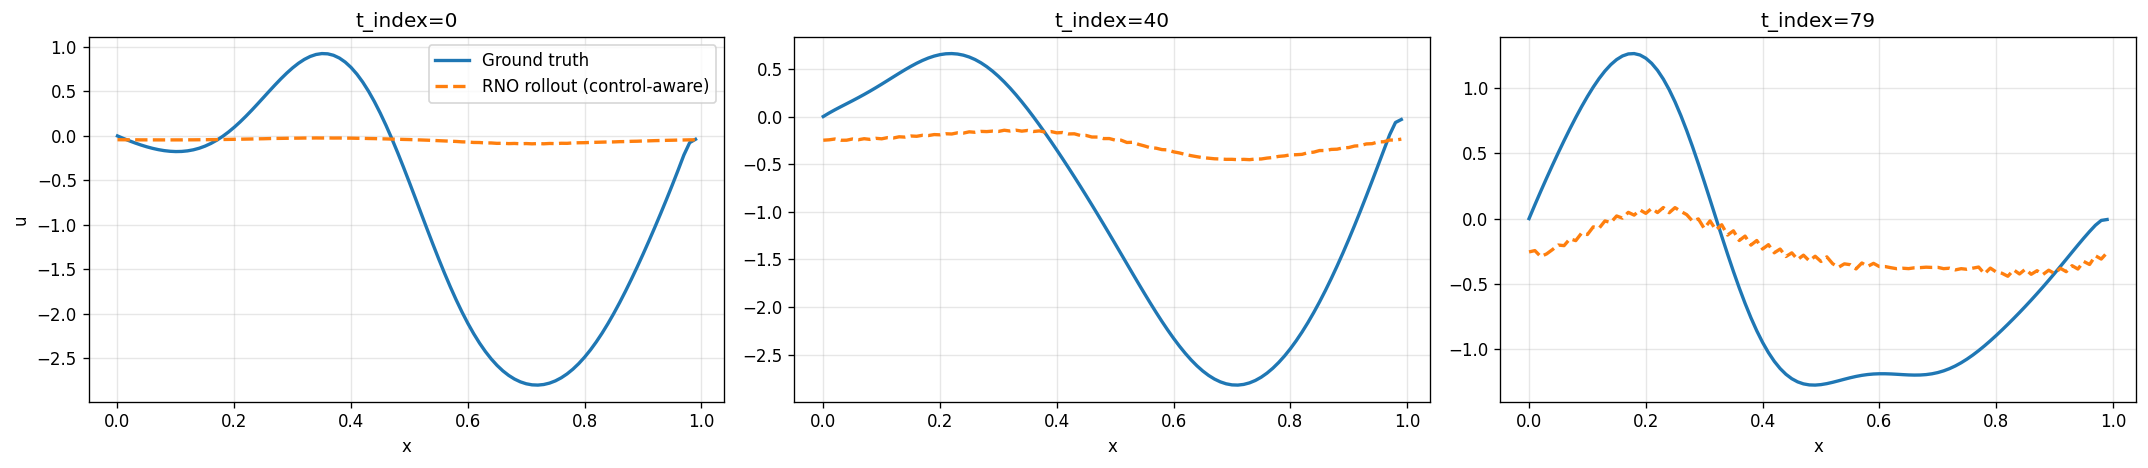

In [ ]:
# 11) Single-Trajectory Native Rollout Test (with controls)
# Native rolled axis: chunk index k (trajectory window steps), not chunk-internal time.
# Control alignment rule: use ctrl_seq[:, k] with current state u_k to predict u_{k+1}.

rollout_h_native = 5
sample_id_native = 0
start_chunk_native = 0
assert rollout_h_native >= 1

traj_sol = sol_test_chunks[sample_id_native]  # (n_chunks, chunk_len, nx, 1)
traj_ctrl = ctrl_test_chunks[sample_id_native]  # (n_chunks, chunk_len, n_ctrl, 1)

if traj_sol.shape[0] != traj_ctrl.shape[0]:
    raise ValueError(
        f"State/control chunk count mismatch: sol={traj_sol.shape[0]}, ctrl={traj_ctrl.shape[0]}"
    )

max_start = traj_sol.shape[0] - n_intervals - rollout_h_native
if max_start < 0:
    raise ValueError(
        f"Not enough chunks for rollout_h={rollout_h_native}. Have n_chunks={traj_sol.shape[0]}, n_intervals={n_intervals}."
    )

start = min(start_chunk_native, max_start)
chunk_len = int(traj_sol.shape[1])
nx_local = int(traj_sol.shape[2])
n_ctrl_local = int(traj_ctrl.shape[2])

# Initial condition is the last state in the history window [start, ..., start+n_intervals-1].
u0_chunk = traj_sol[start + n_intervals - 1]  # (chunk_len, nx, 1)
u0 = u0_chunk.permute(2, 0, 1).unsqueeze(0).to(device).float()  # (1, 1, chunk_len, nx)

# Controls are exogenous and aligned with current rollout state u_k.
ctrl_seq_chunks = traj_ctrl[
    start + n_intervals - 1 : start + n_intervals - 1 + rollout_h_native
]  # (rollout_h, chunk_len, n_ctrl, 1)
ctrl_seq = (
    ctrl_seq_chunks.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
)  # (1, rollout_h, 1, chunk_len, n_ctrl)

# Ground-truth next chunks to compare against predicted rollout chunks.
y_true_chunks = traj_sol[
    start + n_intervals : start + n_intervals + rollout_h_native
]  # (rollout_h, chunk_len, nx, 1)

print("variant:", "sin_embed")
print("traj_sol:", tuple(traj_sol.shape))
print("traj_ctrl:", tuple(traj_ctrl.shape))
print("u0:", tuple(u0.shape))
print("ctrl_seq:", tuple(ctrl_seq.shape))
print("y_true_chunks:", tuple(y_true_chunks.shape))

model.eval()
ar_model.eval()
with torch.no_grad():
    pred_roll = ar_model.rollout(
        u0=u0,
        ctrl_seq=ctrl_seq,
        steps=rollout_h_native,
    )  # (1, rollout_h+1, 1, chunk_len, nx)

if not torch.isfinite(pred_roll).all():
    raise ValueError("Non-finite values encountered in native control-aware rollout.")

pred_chunks = (
    pred_roll[0, 1:].permute(0, 2, 3, 1).detach().cpu()
)  # (rollout_h, chunk_len, nx, 1)
true_chunks = y_true_chunks.detach().cpu()  # (rollout_h, chunk_len, nx, 1)

assert pred_chunks.shape == true_chunks.shape, (
    pred_chunks.shape,
    true_chunks.shape,
)

pred_flat = pred_chunks.squeeze(-1).reshape(rollout_h_native * chunk_len, nx_local)
true_flat = true_chunks.squeeze(-1).reshape(rollout_h_native * chunk_len, nx_local)

mse_roll = torch.mean((pred_flat - true_flat) ** 2).item()
rel_l2_roll = (
    torch.linalg.norm(pred_flat - true_flat) / (torch.linalg.norm(true_flat) + 1e-12)
).item()

print(f"pred_roll shape: {tuple(pred_roll.shape)}")
print(f"pred_chunks shape: {tuple(pred_chunks.shape)}")
print(f"true_chunks shape: {tuple(true_chunks.shape)}")
print(f"Rollout MSE (h={rollout_h_native}): {mse_roll:.4e}")
print(f"Rollout relative L2 (h={rollout_h_native}): {rel_l2_roll:.4e}")

x_axis = x_cord.squeeze().cpu().numpy()
ids = [0, max(0, (rollout_h_native * chunk_len) // 2), rollout_h_native * chunk_len - 1]
fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=120)
for ax, tid in zip(axes, ids):
    ax.plot(
        x_axis,
        true_flat[tid].numpy(),
        label="Ground truth",
        color="#1f77b4",
        linewidth=2,
    )
    ax.plot(
        x_axis,
        pred_flat[tid].numpy(),
        label="RNO rollout (control-aware)",
        color="#ff7f0e",
        linestyle="--",
        linewidth=2,
    )
    ax.set_title(f"t_index={tid}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("u")
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()


## 12) Multi-step fine-tuning helpers (control-aware)
Control-aware multi-horizon endpoint fine-tuning helper routines, mirroring `train_RNO_state_only.ipynb` behavior.


In [82]:
# 12) Multi-step fine-tuning helpers (control-aware)
# Mirrors train_RNO_state_only.run_multistep_finetuning semantics:
# - mixed horizons h=1..fine_tuning_num_steps
# - endpoint-only loss at each horizon h
# - deterministic horizon-specific loaders
# - scheduler stepped every optimization step

# User-editable multi-step controls
fine_tuning_num_steps = 5
fine_tune_ep = 25
fine_tuning_lr = 1e-3
fine_tune_scheduler_step = 2000
fine_tune_scheduler_gamma = 0.5

# history is the number of most recent history states considered for warm-up + u0.
# Must be <= n_intervals (dataset history length produced in section #5).
multi_step_history = n_intervals
# Warm-up steps before rollout; exclude u0 from warm-up to avoid double use.
multi_step_warmup_steps = multi_step_history - 1

if not isinstance(fine_tuning_num_steps, int) or fine_tuning_num_steps < 1:
    raise ValueError(
        f"fine_tuning_num_steps must be int >= 1, got {fine_tuning_num_steps}"
    )
if (
    not isinstance(multi_step_history, int)
    or multi_step_history < 1
    or multi_step_history > n_intervals
):
    raise ValueError(
        f"multi_step_history must be in [1, n_intervals={n_intervals}], got {multi_step_history}"
    )
if (
    not isinstance(multi_step_warmup_steps, int)
    or multi_step_warmup_steps < 0
    or multi_step_warmup_steps > multi_step_history - 1
):
    raise ValueError(
        f"multi_step_warmup_steps must be in [0, multi_step_history-1={multi_step_history - 1}], got {multi_step_warmup_steps}"
    )

horizons = list(range(1, fine_tuning_num_steps + 1))


def build_state_control_windows_horizon(
    sol_chunks, ctrl_chunks, n_intervals_inner, horizon_inner
):
    # sol_chunks:  (n_traj, n_chunks, T, nx, 1)
    # ctrl_chunks: (n_traj, n_chunks, T, n_ctrl, 1)
    x_state_list, x_ctrl_hist_list, ctrl_seq_list, y_list = [], [], [], []

    n_chunks = sol_chunks.shape[1]
    max_i = n_chunks - n_intervals_inner - horizon_inner

    for traj_sol, traj_ctrl in zip(sol_chunks, ctrl_chunks):
        for i in range(max_i):
            # History windows
            x_state_hist = traj_sol[i : i + n_intervals_inner]  # (T_hist, T, nx, 1)
            x_ctrl_hist = traj_ctrl[i : i + n_intervals_inner]  # (T_hist, T, n_ctrl, 1)

            # Control alignment convention: ctrl_k is paired with u_k.
            # u0 is the last state in history at index i+T_hist-1, so first control
            # for rollout is also index i+T_hist-1.
            ctrl_seq_h = traj_ctrl[
                i + n_intervals_inner - 1 : i + n_intervals_inner - 1 + horizon_inner
            ]  # (h, T, n_ctrl, 1)

            # Endpoint target at horizon h (same as state-only routine semantics)
            y_endpoint = traj_sol[
                i + n_intervals_inner + horizon_inner - 1
            ]  # (T, nx, 1)

            x_state_list.append(x_state_hist)
            x_ctrl_hist_list.append(x_ctrl_hist)
            ctrl_seq_list.append(ctrl_seq_h)
            y_list.append(y_endpoint)

    T_local = int(sol_chunks.shape[2])
    nx_local = int(sol_chunks.shape[3])
    n_ctrl_local = int(ctrl_chunks.shape[3])

    if len(x_state_list) == 0:
        x_state_empty = torch.empty(0, n_intervals_inner, 1, T_local, nx_local)
        x_ctrl_hist_empty = torch.empty(0, n_intervals_inner, 1, T_local, n_ctrl_local)
        ctrl_seq_empty = torch.empty(0, horizon_inner, 1, T_local, n_ctrl_local)
        y_empty = torch.empty(0, 1, T_local, nx_local)
        return (
            x_state_empty.float(),
            x_ctrl_hist_empty.float(),
            ctrl_seq_empty.float(),
            y_empty.float(),
        )

    x_state = torch.stack(x_state_list, dim=0).float()  # (N, T_hist, T, nx, 1)
    x_ctrl_hist = torch.stack(
        x_ctrl_hist_list, dim=0
    ).float()  # (N, T_hist, T, n_ctrl, 1)
    ctrl_seq = torch.stack(ctrl_seq_list, dim=0).float()  # (N, h, T, n_ctrl, 1)
    y_endpoint = torch.stack(y_list, dim=0).float()  # (N, T, nx, 1)

    x_state = x_state.permute(0, 1, 4, 2, 3).contiguous()  # (N, T_hist, 1, T, nx)
    x_ctrl_hist = x_ctrl_hist.permute(
        0, 1, 4, 2, 3
    ).contiguous()  # (N, T_hist, 1, T, n_ctrl)
    ctrl_seq = ctrl_seq.permute(0, 1, 4, 2, 3).contiguous()  # (N, h, 1, T, n_ctrl)
    y_endpoint = y_endpoint.permute(0, 3, 1, 2).contiguous()  # (N, 1, T, nx)

    return x_state, x_ctrl_hist, ctrl_seq, y_endpoint


multi_step_train_data = {}
multi_step_test_data = {}
for h in horizons:
    x_state_tr, x_ctrl_hist_tr, ctrl_seq_tr, y_tr = build_state_control_windows_horizon(
        sol_train_chunks,
        ctrl_train_chunks,
        n_intervals,
        h,
    )
    x_state_te, x_ctrl_hist_te, ctrl_seq_te, y_te = build_state_control_windows_horizon(
        sol_test_chunks,
        ctrl_test_chunks,
        n_intervals,
        h,
    )
    multi_step_train_data[h] = (x_state_tr, x_ctrl_hist_tr, ctrl_seq_tr, y_tr)
    multi_step_test_data[h] = (x_state_te, x_ctrl_hist_te, ctrl_seq_te, y_te)

n_eval_per_horizon = {h: multi_step_test_data[h][0].shape[0] for h in horizons}
print("Multi-step evaluation samples per horizon:", n_eval_per_horizon)


def run_multistep_finetuning(
    model_obj,
    ar_model_obj,
    train_data_by_h,
    test_data_by_h,
    ft_seed,
    n_epochs=None,
    steps_per_epoch=None,
    history=None,
    warmup_steps=None,
):
    if n_epochs is None:
        n_epochs = fine_tune_ep

    # Build deterministic train loaders per horizon.
    train_loaders = {}
    test_loaders = {}
    for h in horizons:
        xh_state_tr, xh_ctrl_hist_tr, xh_ctrl_seq_tr, yh_tr = train_data_by_h[h]
        xh_state_te, xh_ctrl_hist_te, xh_ctrl_seq_te, yh_te = test_data_by_h[h]

        g_h = torch.Generator(device="cpu")
        g_h.manual_seed(ft_seed)

        train_loaders[h] = DataLoader(
            torch.utils.data.TensorDataset(
                xh_state_tr, xh_ctrl_hist_tr, xh_ctrl_seq_tr, yh_tr
            ),
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
            generator=g_h,
        )
        test_loaders[h] = DataLoader(
            torch.utils.data.TensorDataset(
                xh_state_te, xh_ctrl_hist_te, xh_ctrl_seq_te, yh_te
            ),
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
        )

    # KS-style mixed horizon list: one entry per batch in each horizon loader.
    multi_step_list_template = []
    for h in horizons:
        multi_step_list_template += [h for _ in range(len(train_loaders[h]))]

    optimizer_ft = torch.optim.Adam(
        model_obj.parameters(), lr=fine_tuning_lr, weight_decay=weight_decay
    )
    scheduler_ft = torch.optim.lr_scheduler.StepLR(
        optimizer_ft,
        step_size=fine_tune_scheduler_step,
        gamma=fine_tune_scheduler_gamma,
    )

    ft_logs = {
        "train_rel_l2": {h: [] for h in horizons},
        "test_rel_l2": {h: [] for h in horizons},
    }

    def _rollout_with_history_warmup(
        x_state_hist,
        x_ctrl_hist,
        x_ctrl_seq,
        steps,
    ):
        # x_state_hist: (B, T_hist, 1, T, nx)
        # x_ctrl_hist:  (B, T_hist, 1, T, n_ctrl)
        # x_ctrl_seq:   (B, steps, 1, T, n_ctrl)
        t_hist = x_state_hist.shape[1]
        if history is None:
            history_eff = t_hist
        else:
            history_eff = int(history)

        if history_eff < 1 or history_eff > t_hist:
            raise ValueError(f"history must be in [1, {t_hist}], got {history_eff}")

        max_warmup = history_eff - 1
        if warmup_steps is None:
            warmup_steps_eff = max_warmup
        else:
            warmup_steps_eff = int(warmup_steps)

        if warmup_steps_eff < 0 or warmup_steps_eff > max_warmup:
            raise ValueError(
                f"warmup_steps must be in [0, {max_warmup}] for history={history_eff}, got {warmup_steps_eff}"
            )
        if x_ctrl_seq.shape[1] < steps:
            raise ValueError(
                f"x_ctrl_seq has {x_ctrl_seq.shape[1]} controls but steps={steps}"
            )

        history_start = t_hist - history_eff  # use most recent history_eff states

        hidden_states = None
        # Warm-up on first warmup_steps entries of the selected history window.
        for t in range(history_start, history_start + warmup_steps_eff):
            u_t_hist = x_state_hist[:, t]  # (B, 1, T, nx)
            ctrl_t_hist = x_ctrl_hist[:, t]  # (B, 1, T, n_ctrl)
            _, hidden_states = ar_model_obj.forward_one(
                u_t_hist,
                ctrl_t_hist,
                hidden_states=hidden_states,
                return_hidden_states=True,
            )

        # Start rollout from u0 with ctrl_seq[:, 0], then carry hidden state.
        current_state = x_state_hist[:, -1]  # (B, 1, T, nx)
        traj = [current_state]
        for k in range(steps):
            ctrl_t = x_ctrl_seq[:, k]  # (B, 1, T, n_ctrl)
            u_next, hidden_states = ar_model_obj.forward_one(
                current_state,
                ctrl_t,
                hidden_states=hidden_states,
                return_hidden_states=True,
            )
            traj.append(u_next)
            current_state = u_next

        return torch.stack(traj, dim=1), history_eff, warmup_steps_eff

    print("Begin multi-step fine-tuning:")
    rng_ft = random.Random(ft_seed)
    debug_shapes_printed = False

    for ep in range(1, n_epochs + 1):
        t_start = time.time()

        multi_step_list = multi_step_list_template.copy()
        rng_ft.shuffle(multi_step_list)
        if steps_per_epoch is not None:
            steps_per_epoch = int(steps_per_epoch)
            multi_step_list = multi_step_list[
                : max(0, min(steps_per_epoch, len(multi_step_list)))
            ]

        iters = {h: iter(train_loaders[h]) for h in horizons}

        model_obj.train()
        ar_model_obj.train()
        train_l2_sum = {h: 0.0 for h in horizons}
        train_count = {h: 0 for h in horizons}

        for h in tqdm(multi_step_list, total=len(multi_step_list)):
            xb_state, xb_ctrl_hist, xb_ctrl_seq, yb = next(iters[h])
            xb_state = xb_state.to(device).float()  # (B, T_hist, 1, T, nx)
            xb_ctrl_hist = xb_ctrl_hist.to(device).float()  # (B, T_hist, 1, T, n_ctrl)
            xb_ctrl_seq = xb_ctrl_seq.to(device).float()  # (B, h, 1, T, n_ctrl)
            yb = yb.to(device).float()  # (B, 1, T, nx)

            if xb_state.ndim != 5 or xb_state.shape[2] != 1:
                raise ValueError(
                    f"Expected xb_state (B,T_hist,1,T,nx), got {tuple(xb_state.shape)}"
                )
            if xb_ctrl_hist.ndim != 5 or xb_ctrl_hist.shape[2] != 1:
                raise ValueError(
                    f"Expected xb_ctrl_hist (B,T_hist,1,T,n_ctrl), got {tuple(xb_ctrl_hist.shape)}"
                )
            if (
                xb_ctrl_seq.ndim != 5
                or xb_ctrl_seq.shape[1] != h
                or xb_ctrl_seq.shape[2] != 1
            ):
                raise ValueError(
                    f"Expected xb_ctrl_seq (B,{h},1,T,n_ctrl), got {tuple(xb_ctrl_seq.shape)}"
                )
            if yb.ndim != 4 or yb.shape[1] != 1:
                raise ValueError(f"Expected yb (B,1,T,nx), got {tuple(yb.shape)}")

            pred_rollout, history_eff, warmup_steps_eff = _rollout_with_history_warmup(
                x_state_hist=xb_state,
                x_ctrl_hist=xb_ctrl_hist,
                x_ctrl_seq=xb_ctrl_seq,
                steps=h,
            )
            out_window = pred_rollout[:, -1]  # (B, 1, T, nx)

            if not debug_shapes_printed:
                print("xb_state shape:", tuple(xb_state.shape))
                print("xb_ctrl_hist shape:", tuple(xb_ctrl_hist.shape))
                print("xb_ctrl_seq shape:", tuple(xb_ctrl_seq.shape))
                print("history used:", history_eff)
                print("warmup_steps used:", warmup_steps_eff)
                print("u0 shape:", tuple(xb_state[:, -1].shape))
                print("ctrl_seq[:, 0] shape:", tuple(xb_ctrl_seq[:, 0].shape))
                print("pred_rollout shape:", tuple(pred_rollout.shape))
                print("pred_rollout[:, -1] shape:", tuple(pred_rollout[:, -1].shape))
                print("yb shape:", tuple(yb.shape))
                debug_shapes_printed = True

            l2 = lploss(out_window, yb)

            optimizer_ft.zero_grad()
            l2.backward()
            optimizer_ft.step()
            scheduler_ft.step()

            train_l2_sum[h] += l2.item()
            train_count[h] += xb_state.size(0)

        model_obj.eval()
        ar_model_obj.eval()
        test_rel_sum = {h: 0.0 for h in horizons}
        test_count = {h: 0 for h in horizons}

        with torch.no_grad():
            for h in horizons:
                for xb_state, xb_ctrl_hist, xb_ctrl_seq, yb in test_loaders[h]:
                    xb_state = xb_state.to(device).float()
                    xb_ctrl_hist = xb_ctrl_hist.to(device).float()
                    xb_ctrl_seq = xb_ctrl_seq.to(device).float()
                    yb = yb.to(device).float()

                    pred_rollout, _, _ = _rollout_with_history_warmup(
                        x_state_hist=xb_state,
                        x_ctrl_hist=xb_ctrl_hist,
                        x_ctrl_seq=xb_ctrl_seq,
                        steps=h,
                    )
                    out_window = pred_rollout[:, -1]  # (B, 1, T, nx)

                    test_rel_sum[h] += lploss(out_window, yb).item()
                    test_count[h] += xb_state.size(0)

        train_l2_list = []
        test_l2_list = []
        for h in horizons:
            train_l2_h = train_l2_sum[h] / max(train_count[h], 1)
            test_l2_h = test_rel_sum[h] / max(test_count[h], 1)

            ft_logs["train_rel_l2"][h].append(train_l2_h)
            ft_logs["test_rel_l2"][h].append(test_l2_h)

            train_l2_list.append(train_l2_h)
            test_l2_list.append(test_l2_h)

        runtime = time.time() - t_start
        print(
            f"Fine-tune epoch: {ep} Time: {runtime:.2f} Train L2: {train_l2_list} Test L2: {test_l2_list}"
        )

    return ft_logs


Multi-step evaluation samples per horizon: {1: 1520, 2: 1440, 3: 1360, 4: 1280, 5: 1200}


## 13) Multi-step fine-tuning sanity
Runs one minimal fine-tuning update (`n_epochs=1`, `steps_per_epoch=1`) on a copied model/wrapper and checks endpoint-shape + finiteness.


In [83]:
# 13) Multi-step fine-tuning sanity (1 epoch, 1 step)
import copy

h_smoke = min(2, fine_tuning_num_steps)
xh_state, xh_ctrl_hist, xh_ctrl_seq, yh = multi_step_train_data[h_smoke]

if xh_state.shape[0] == 0:
    raise ValueError(f"No multi-step samples available for h={h_smoke}")

assert xh_state.shape[1:] == (n_intervals, 1, T, xh_state.shape[-1]), xh_state.shape
assert xh_ctrl_hist.shape[1] == n_intervals, xh_ctrl_hist.shape
assert xh_ctrl_seq.shape[1] == h_smoke, xh_ctrl_seq.shape
assert yh.shape[1:] == (1, T, yh.shape[-1]), yh.shape

model_smoke = copy.deepcopy(model).to(device)
ar_model_smoke = RNOControlARSinEmbed(
    rno=model_smoke, control_lifter=control_lifter
).to(device)

ft_logs_smoke = run_multistep_finetuning(
    model_obj=model_smoke,
    ar_model_obj=ar_model_smoke,
    train_data_by_h=multi_step_train_data,
    test_data_by_h=multi_step_test_data,
    ft_seed=seed,
    n_epochs=1,
    steps_per_epoch=1,
    history=multi_step_history,
    warmup_steps=multi_step_warmup_steps,
)

B_smoke = min(2, xh_state.shape[0])
xb_state = xh_state[:B_smoke].to(device).float()  # (B, T_hist, 1, T, nx)
xb_ctrl_seq = xh_ctrl_seq[:B_smoke].to(device).float()  # (B, h, 1, T, n_ctrl)
yb = yh[:B_smoke].to(device).float()  # (B, 1, T, nx)

with torch.no_grad():
    pred_roll_smoke = ar_model_smoke.rollout(
        u0=xb_state[:, -1],
        ctrl_seq=xb_ctrl_seq,
        steps=h_smoke,
    )  # (B, h+1, 1, T, nx)

pred_endpoint = pred_roll_smoke[:, -1]  # (B, 1, T, nx)
assert pred_endpoint.shape == yb.shape, (pred_endpoint.shape, yb.shape)
assert torch.isfinite(pred_roll_smoke).all(), "Non-finite values in smoke rollout"

print("Smoke fine-tune logs keys:", ft_logs_smoke.keys())
print("Smoke pred_rollout shape:", tuple(pred_roll_smoke.shape))
print("Smoke endpoint shape:", tuple(pred_endpoint.shape), "target:", tuple(yb.shape))
print("Multi-step fine-tuning sanity passed.")


Begin multi-step fine-tuning:


  0%|          | 0/1 [00:00<?, ?it/s]

xb_state shape: (75, 5, 1, 16, 100)
xb_ctrl_hist shape: (75, 5, 1, 16, 4)
xb_ctrl_seq shape: (75, 4, 1, 16, 4)
history used: 5
warmup_steps used: 4
u0 shape: (75, 1, 16, 100)
ctrl_seq[:, 0] shape: (75, 1, 16, 4)
pred_rollout shape: (75, 5, 1, 16, 100)
pred_rollout[:, -1] shape: (75, 1, 16, 100)
yb shape: (75, 1, 16, 100)
Fine-tune epoch: 1 Time: 48.51 Train L2: [0.0, 0.0, 0.0, 6.695537923177083, 0.0] Test L2: [1.269702478459007, 1.9497113903363545, 2.786483725379495, 4.126127660274506, 5.549148610432943]
Smoke fine-tune logs keys: dict_keys(['train_rel_l2', 'test_rel_l2'])
Smoke pred_rollout shape: (2, 3, 1, 16, 100)
Smoke endpoint shape: (2, 1, 16, 100) target: (2, 1, 16, 100)
Multi-step fine-tuning sanity passed.


## 14) Multi-step fine-tuning training run
Runs the full control-aware multi-step fine-tuning loop over horizons 1..5 for 25 epochs.


In [84]:
# 14) Multi-step fine-tuning training run
# Uses user-editable config from section #12:
# - fine_tuning_num_steps
# - multi_step_history
# - multi_step_warmup_steps

fine_tune_ep_run = fine_tune_ep  # user-editable run epochs for this execution

if not isinstance(fine_tune_ep_run, int) or fine_tune_ep_run < 1:
    raise ValueError(f"fine_tune_ep_run must be int >= 1, got {fine_tune_ep_run}")
if not isinstance(fine_tuning_num_steps, int) or fine_tuning_num_steps < 1:
    raise ValueError(
        f"fine_tuning_num_steps must be int >= 1, got {fine_tuning_num_steps}"
    )
if (
    not isinstance(multi_step_history, int)
    or multi_step_history < 1
    or multi_step_history > n_intervals
):
    raise ValueError(
        f"multi_step_history must be in [1, n_intervals={n_intervals}], got {multi_step_history}"
    )
if (
    not isinstance(multi_step_warmup_steps, int)
    or multi_step_warmup_steps < 0
    or multi_step_warmup_steps > multi_step_history - 1
):
    raise ValueError(
        f"multi_step_warmup_steps must be in [0, multi_step_history-1={multi_step_history - 1}], got {multi_step_warmup_steps}"
    )

expected_horizons = list(range(1, fine_tuning_num_steps + 1))
if horizons != expected_horizons:
    raise ValueError(
        "`horizons` is out of sync with `fine_tuning_num_steps`. "
        "Re-run section #12 after editing fine_tuning_num_steps."
    )

# Ensure horizon data dictionaries are aligned with configured horizons.
for h in horizons:
    if h not in multi_step_train_data or h not in multi_step_test_data:
        raise ValueError(
            f"Missing multi-step dataset for horizon h={h}. "
            "Re-run section #12 after changing fine_tuning_num_steps."
        )

multistep_finetune_logs = run_multistep_finetuning(
    model_obj=model,
    ar_model_obj=ar_model,
    train_data_by_h=multi_step_train_data,
    test_data_by_h=multi_step_test_data,
    ft_seed=seed,
    n_epochs=fine_tune_ep_run,
    history=multi_step_history,
    warmup_steps=multi_step_warmup_steps,
)

print("Completed multi-step fine-tuning.")
print("Config:")
print("  fine_tuning_num_steps:", fine_tuning_num_steps)
print("  horizons:", horizons)
print("  history:", multi_step_history)
print("  warmup_steps:", multi_step_warmup_steps)
print("  fine_tune_ep_run:", fine_tune_ep_run)
print("Logged horizons:", list(multistep_finetune_logs["train_rel_l2"].keys()))
print(
    "Final train L2 per horizon:",
    [multistep_finetune_logs["train_rel_l2"][h][-1] for h in horizons],
)
print(
    "Final test L2 per horizon:",
    [multistep_finetune_logs["test_rel_l2"][h][-1] for h in horizons],
)


Begin multi-step fine-tuning:


  0%|          | 0/361 [00:00<?, ?it/s]

xb_state shape: (75, 5, 1, 16, 100)
xb_ctrl_hist shape: (75, 5, 1, 16, 4)
xb_ctrl_seq shape: (75, 4, 1, 16, 4)
history used: 5
warmup_steps used: 4
u0 shape: (75, 1, 16, 100)
ctrl_seq[:, 0] shape: (75, 1, 16, 4)
pred_rollout shape: (75, 5, 1, 16, 100)
pred_rollout[:, -1] shape: (75, 1, 16, 100)
yb shape: (75, 1, 16, 100)
Fine-tune epoch: 1 Time: 126.74 Train L2: [0.9037608368799029, 0.9617574370534796, 0.9356676857559769, 1.1113237635294597, 1.5802993194262187] Test L2: [0.7665824902685066, 0.8036870453092787, 0.8587425519438351, 0.9164863549172878, 1.0100478553771972]


  0%|          | 0/361 [00:00<?, ?it/s]

Fine-tune epoch: 2 Time: 114.77 Train L2: [0.7662714941707658, 0.7973111905549702, 0.8243770924320928, 0.8577694612390855, 0.9547345272699992] Test L2: [0.7143136074668482, 0.742188020547231, 0.7703236320439507, 0.8051019378006459, 0.8654119936625163]


...

Fine-tune epoch: 23 Time: 109.06 Train L2: [0.05752387804258998, 0.0742146430935776, 0.10139327155219184, 0.13265395014893774, 0.1744738656282425] Test L2: [0.06099089258595517, 0.08354998975992203, 0.11616818580557318, 0.1550050991587341, 0.20054014523824057]


  0%|          | 0/361 [00:00<?, ?it/s]

Fine-tune epoch: 24 Time: 109.05 Train L2: [0.0560847873452269, 0.0727296144920483, 0.099508871767256, 0.1294311242945054, 0.16742080330848694] Test L2: [0.05697158531923043, 0.07544802708758248, 0.10941696920815636, 0.147848098911345, 0.19593985478083292]


  0%|          | 0/361 [00:00<?, ?it/s]

Fine-tune epoch: 25 Time: 109.26 Train L2: [0.0559628245663741, 0.07250937813206723, 0.10103172169791327, 0.12976236661275228, 0.16816004971663157] Test L2: [0.05655447550510105, 0.07735225699014134, 0.1146469689467374, 0.1521772349253297, 0.19763964811960857]
Completed multi-step fine-tuning.
Config:
  fine_tuning_num_steps: 5
  horizons: [1, 2, 3, 4, 5]
  history: 5
  warmup_steps: 4
  fine_tune_ep_run: 25
Logged horizons: [1, 2, 3, 4, 5]
Final train L2 per horizon: [0.0559628245663741, 0.07250937813206723, 0.10103172169791327, 0.12976236661275228, 0.16816004971663157]
Final test L2 per horizon: [0.05655447550510105, 0.07735225699014134, 0.1146469689467374, 0.1521772349253297, 0.19763964811960857]


In [85]:
# 14b) Save fine-tuned checkpoint with rich metadata
from datetime import datetime, timezone
import subprocess

if "multistep_finetune_logs" not in globals():
    raise ValueError(
        "Run section #14 first so the model is fine-tuned and `multistep_finetune_logs` exists."
    )

# Representative batch shapes before model input lifting.
xb_state_ckpt, xb_ctrl_ckpt, yb_ckpt = next(iter(train_loader))
xb_state_ckpt = xb_state_ckpt.float()  # (B, T_hist, 1, 16, 100)
xb_ctrl_ckpt = xb_ctrl_ckpt.float()  # (B, T_hist, 1, 16, control_dim)
yb_ckpt = yb_ckpt.float()  # (B, 1, 16, 100)

with torch.no_grad():
    x_in_ckpt = build_rno_input(
        xb_state_ckpt.to(device),
        xb_ctrl_ckpt.to(device),
    )  # (B, T_hist, in_channels, 16, 100)

# Try to capture git commit; keep key even if unavailable.
try:
    git_commit = (
        subprocess.check_output(["git", "rev-parse", "HEAD"], stderr=subprocess.DEVNULL)
        .decode("utf-8")
        .strip()
    )
except Exception:
    git_commit = None

created_at_utc = datetime.now(timezone.utc).isoformat()
ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

experiment_id = globals().get(
    "experiment_id",
    f"rno_heat_control_sin_embed__seed{seed}__{ts}",
)

result_dir_ft = os.path.join(os.getcwd(), f"result_rno_{seed}_sin_embed")
os.makedirs(result_dir_ft, exist_ok=True)
ckpt_name_ft = f"rno_sin_embed_finetune_seed{seed}_H{fine_tuning_num_steps}_{ts}.pt"
ckpt_path_ft = os.path.join(result_dir_ft, ckpt_name_ft)

train_num_samples = (
    len(train_loader.dataset) if hasattr(train_loader, "dataset") else None
)
test_num_samples = len(test_loader.dataset) if hasattr(test_loader, "dataset") else None

ckpt_finetune = {
    "schema_version": "rno_heat_control_sin_embed.v1",
    "created_at_utc": created_at_utc,
    "notebook": "train_RNO_sin_embed.ipynb",
    "strategy": "sin_embed",
    "experiment_id": experiment_id,
    "seed": int(seed),
    "git_commit": git_commit,
    "model_state_dict": model.state_dict(),
    "model_kwargs": {
        "n_modes": (modes1, modes2),
        "hidden_channels": width,
        "in_channels": in_channels,
        "out_channels": out_channels,
        "n_layers": n_layers,
        "domain_padding": domain_padding,
    },
    "model_class": type(model).__name__,
    "wrapper_class": type(ar_model).__name__ if "ar_model" in globals() else None,
    "data": {
        "state_shape": tuple(xb_state_ckpt.shape),
        "control_shape": tuple(xb_ctrl_ckpt.shape),
        "target_shape": tuple(yb_ckpt.shape),
        "rno_input_shape": tuple(x_in_ckpt.shape),
        "train_num_samples": train_num_samples,
        "val_num_samples": None,
        "test_num_samples": test_num_samples,
        "train_num_batches": len(train_loader),
        "val_num_batches": None,
        "test_num_batches": len(test_loader),
        "sample_count_note": "No validation loader in this notebook; val_* fields are None.",
        "batch_size": int(batch_size),
        "T_hist": int(n_intervals),
        "rollout_h_train": int(fine_tuning_num_steps),
        "nx": int(xb_state_ckpt.shape[-1]),
        "n_intervals": int(xb_state_ckpt.shape[-2]),
        "control_dim": int(xb_ctrl_ckpt.shape[-1]),
    },
    "hparams": {
        "baseline": {
            "epochs": int(epochs),
            "learning_rate": float(learning_rate),
            "weight_decay": float(weight_decay),
            "scheduler_step": int(scheduler_step),
            "scheduler_gamma": float(scheduler_gamma),
            "batch_size": int(batch_size),
        },
        "finetune": {
            "fine_tune_ep": int(fine_tune_ep),
            "fine_tuning_lr": float(fine_tuning_lr),
            "fine_tuning_num_steps": int(fine_tuning_num_steps),
            "fine_tune_scheduler_step": int(fine_tune_scheduler_step),
            "fine_tune_scheduler_gamma": float(fine_tune_scheduler_gamma),
            "horizons": list(horizons),
        },
        "reproducibility": {
            "seed": int(seed),
            "cudnn_deterministic": bool(torch.backends.cudnn.deterministic),
            "cudnn_benchmark": bool(torch.backends.cudnn.benchmark),
        },
    },
    "metrics": {
        "endpoint_by_horizon": globals().get("endpoint_eval_results", None),
        "baseline_history": {
            "train_loss_history": globals().get("training_loss_history", None),
            "test_loss_history": globals().get("test_loss_history", None),
        }
        if "training_loss_history" in globals() and "test_loss_history" in globals()
        else None,
        "finetune_history": globals().get("multistep_finetune_logs", None),
    },
}

torch.save(ckpt_finetune, ckpt_path_ft)

print(f"Saved fine-tuned checkpoint: {ckpt_path_ft}")
print("schema_version:", ckpt_finetune["schema_version"])
print(
    "state/control/rno_input/target:",
    ckpt_finetune["data"]["state_shape"],
    ckpt_finetune["data"]["control_shape"],
    ckpt_finetune["data"]["rno_input_shape"],
    ckpt_finetune["data"]["target_shape"],
)
print(
    "finetune horizon + epochs:",
    ckpt_finetune["data"]["rollout_h_train"],
    ckpt_finetune["hparams"]["finetune"]["fine_tune_ep"],
)
print("top-level keys:", list(ckpt_finetune.keys()))


Saved fine-tuned checkpoint: /home/pk222/projects/tipping-point-forecast/heat/result_rno_32_sin_embed/rno_sin_embed_finetune_seed32_H5_20260302T144609Z.pt
schema_version: rno_heat_control_sin_embed.v1
state/control/rno_input/target: (75, 5, 1, 16, 100) (75, 5, 1, 16, 4) (75, 5, 2, 16, 100) (75, 1, 16, 100)
finetune horizon + epochs: 5 25
top-level keys: ['schema_version', 'created_at_utc', 'notebook', 'strategy', 'experiment_id', 'seed', 'git_commit', 'model_state_dict', 'model_kwargs', 'model_class', 'wrapper_class', 'data', 'hparams', 'metrics']


## 15) Single-Trajectory Native Rollout Test (with controls) after multi-step fine-tuning
Repeats section #11 after section #14 multi-step fine-tuning, using the same native chunk-axis rollout and control alignment.


variant: sin_embed
context: post-multistep-finetune
traj_sol: (25, 16, 100, 1)
traj_ctrl: (25, 16, 4, 1)
u0: (1, 1, 16, 100)
ctrl_seq: (1, 5, 1, 16, 4)
y_true_chunks: (5, 16, 100, 1)
n_ctrl: 4
pred_roll shape: (1, 6, 1, 16, 100)
pred_chunks shape: (5, 16, 100, 1)
true_chunks shape: (5, 16, 100, 1)
Post-finetune rollout MSE (h=5): 1.8473e+00
Post-finetune rollout relative L2 (h=5): 9.4787e-01


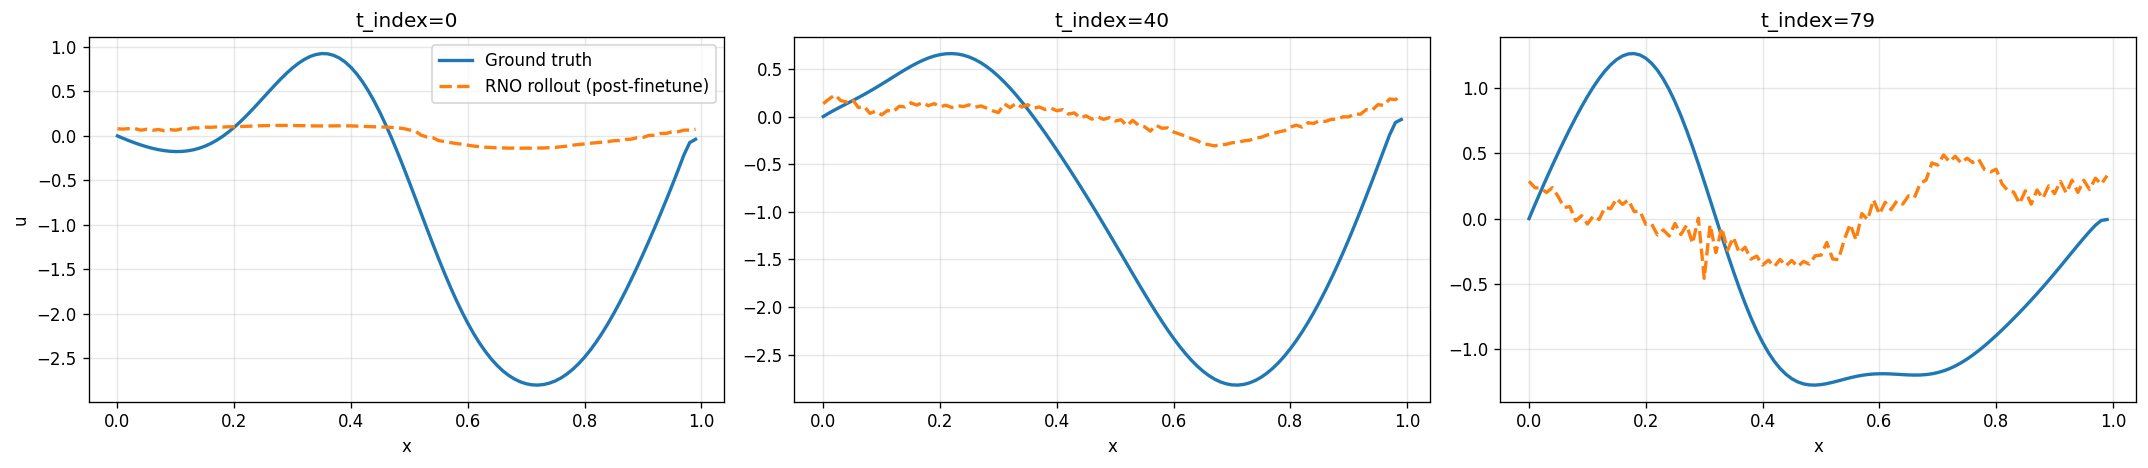

In [44]:
# 15) Single-Trajectory Native Rollout Test (with controls) after multi-step fine-tuning
# Native rolled axis: chunk index k (trajectory window steps), not chunk-internal time.
# Control alignment rule: use ctrl_seq[:, k] with current state u_k to predict u_{k+1}.

if "multistep_finetune_logs" not in globals():
    raise ValueError("Run section #14 first to produce `multistep_finetune_logs`.")

rollout_h_native_ft = fine_tuning_num_steps
sample_id_native_ft = 0
start_chunk_native_ft = 0
assert rollout_h_native_ft >= 1

traj_sol_ft = sol_test_chunks[sample_id_native_ft]  # (n_chunks, chunk_len, nx, 1)
traj_ctrl_ft = ctrl_test_chunks[sample_id_native_ft]  # (n_chunks, chunk_len, n_ctrl, 1)

if traj_sol_ft.shape[0] != traj_ctrl_ft.shape[0]:
    raise ValueError(
        f"State/control chunk count mismatch: sol={traj_sol_ft.shape[0]}, ctrl={traj_ctrl_ft.shape[0]}"
    )

max_start_ft = traj_sol_ft.shape[0] - n_intervals - rollout_h_native_ft
if max_start_ft < 0:
    raise ValueError(
        f"Not enough chunks for rollout_h={rollout_h_native_ft}. Have n_chunks={traj_sol_ft.shape[0]}, n_intervals={n_intervals}."
    )

start_ft = min(start_chunk_native_ft, max_start_ft)
chunk_len_ft = int(traj_sol_ft.shape[1])
nx_local_ft = int(traj_sol_ft.shape[2])
n_ctrl_local_ft = int(traj_ctrl_ft.shape[2])

# Initial condition is the last state in the history window [start, ..., start+n_intervals-1].
u0_chunk_ft = traj_sol_ft[start_ft + n_intervals - 1]  # (chunk_len, nx, 1)
u0_ft = (
    u0_chunk_ft.permute(2, 0, 1).unsqueeze(0).to(device).float()
)  # (1, 1, chunk_len, nx)

# Controls are exogenous and aligned with current rollout state u_k.
ctrl_seq_chunks_ft = traj_ctrl_ft[
    start_ft + n_intervals - 1 : start_ft + n_intervals - 1 + rollout_h_native_ft
]  # (rollout_h, chunk_len, n_ctrl, 1)
ctrl_seq_ft = (
    ctrl_seq_chunks_ft.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
)  # (1, rollout_h, 1, chunk_len, n_ctrl)

# Ground-truth next chunks to compare against predicted rollout chunks.
y_true_chunks_ft = traj_sol_ft[
    start_ft + n_intervals : start_ft + n_intervals + rollout_h_native_ft
]  # (rollout_h, chunk_len, nx, 1)

print("variant:", "sin_embed")
print("context:", "post-multistep-finetune")
print("traj_sol:", tuple(traj_sol_ft.shape))
print("traj_ctrl:", tuple(traj_ctrl_ft.shape))
print("u0:", tuple(u0_ft.shape))
print("ctrl_seq:", tuple(ctrl_seq_ft.shape))
print("y_true_chunks:", tuple(y_true_chunks_ft.shape))
print("n_ctrl:", n_ctrl_local_ft)

model.eval()
ar_model.eval()
with torch.no_grad():
    pred_roll_ft = ar_model.rollout(
        u0=u0_ft,
        ctrl_seq=ctrl_seq_ft,
        steps=rollout_h_native_ft,
    )  # (1, rollout_h+1, 1, chunk_len, nx)

if not torch.isfinite(pred_roll_ft).all():
    raise ValueError("Non-finite values encountered in post-finetune rollout.")

pred_chunks_ft = (
    pred_roll_ft[0, 1:].permute(0, 2, 3, 1).detach().cpu()
)  # (rollout_h, chunk_len, nx, 1)
true_chunks_ft = y_true_chunks_ft.detach().cpu()  # (rollout_h, chunk_len, nx, 1)

assert pred_chunks_ft.shape == true_chunks_ft.shape, (
    pred_chunks_ft.shape,
    true_chunks_ft.shape,
)

pred_flat_ft = pred_chunks_ft.squeeze(-1).reshape(
    rollout_h_native_ft * chunk_len_ft, nx_local_ft
)
true_flat_ft = true_chunks_ft.squeeze(-1).reshape(
    rollout_h_native_ft * chunk_len_ft, nx_local_ft
)

mse_roll_ft = torch.mean((pred_flat_ft - true_flat_ft) ** 2).item()
rel_l2_roll_ft = (
    torch.linalg.norm(pred_flat_ft - true_flat_ft)
    / (torch.linalg.norm(true_flat_ft) + 1e-12)
).item()

print(f"pred_roll shape: {tuple(pred_roll_ft.shape)}")
print(f"pred_chunks shape: {tuple(pred_chunks_ft.shape)}")
print(f"true_chunks shape: {tuple(true_chunks_ft.shape)}")
print(f"Post-finetune rollout MSE (h={rollout_h_native_ft}): {mse_roll_ft:.4e}")
print(
    f"Post-finetune rollout relative L2 (h={rollout_h_native_ft}): {rel_l2_roll_ft:.4e}"
)

x_axis_ft = x_cord.squeeze().cpu().numpy()
ids_ft = [
    0,
    max(0, (rollout_h_native_ft * chunk_len_ft) // 2),
    rollout_h_native_ft * chunk_len_ft - 1,
]
fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=120)
for ax, tid in zip(axes, ids_ft):
    ax.plot(
        x_axis_ft,
        true_flat_ft[tid].numpy(),
        label="Ground truth",
        color="#1f77b4",
        linewidth=2,
    )
    ax.plot(
        x_axis_ft,
        pred_flat_ft[tid].numpy(),
        label="RNO rollout (post-finetune)",
        color="#ff7f0e",
        linestyle="--",
        linewidth=2,
    )
    ax.set_title(f"t_index={tid}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("u")
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()


## 16) Endpoint evaluation plan
- **Goal:** compute endpoint Relative L2 for multiple rollout horizons using control-aware autoregressive rollout.
- **Batch contract:** `(x_state_hist, x_ctrl_hist, x_ctrl_seq, y_endpoint)` with shapes `(B, T_hist, 1, 16, 100)`, `(B, T_hist, 1, 16, n_ctrl)`, `(B, H, 1, 16, n_ctrl)`, `(B, 1, 16, 100)`.
- **Rollout start:** `u0 = x_state_hist[:, -1]` (last state in history).
- **Control alignment:** at rollout step `k`, use `ctrl_seq[:, k]` aligned with `u_k` (same wrapper convention used in training).
- **Endpoint definition:** compare only final prediction `u_{t+H}` (`pred_roll[:, -1]`) against `y_endpoint`.
- **Strategy handling:** wrapper (`ar_model`) applies strategy-specific lifting internally (broadcast / sin-embed / gaussian actuators).
- **Default eval steps:** bounded by `H_train=fine_tuning_num_steps`, plus at most one boundary step `H_train+1` if data is available.


In [86]:
# 16) Endpoint evaluation utilities (control-aware)
def evaluate_endpoint_metrics(
    ar_model_obj,
    eval_loaders_by_h,
    eval_steps,
    device,
    H_train,
):
    """Evaluate endpoint Relative L2 per horizon using control-aware rollout."""
    eval_steps = [int(h) for h in eval_steps]
    if len(eval_steps) == 0:
        raise ValueError("eval_steps must be non-empty")

    if max(eval_steps) > int(H_train):
        print(
            f"Warning: Evaluating beyond trained horizon (H_train={H_train}). Errors may be unstable and not comparable."
        )

    ar_model_obj.eval()
    results = {}
    printed_shapes = False

    with torch.no_grad():
        for h in eval_steps:
            if h not in eval_loaders_by_h:
                raise ValueError(f"No evaluation loader for horizon h={h}")

            loader = eval_loaders_by_h[h]
            rel_sum = 0.0
            n_total = 0

            for x_state_hist, x_ctrl_hist, x_ctrl_seq, y_endpoint in loader:
                x_state_hist = x_state_hist.to(
                    device
                ).float()  # (B, T_hist, 1, 16, 100)
                x_ctrl_hist = x_ctrl_hist.to(
                    device
                ).float()  # (B, T_hist, 1, 16, n_ctrl)
                x_ctrl_seq = x_ctrl_seq.to(device).float()  # (B, h, 1, 16, n_ctrl)
                y_endpoint = y_endpoint.to(device).float()  # (B, 1, 16, 100)

                if x_ctrl_seq.shape[1] < h:
                    raise ValueError(
                        f"Requested h={h}, but ctrl_seq has only {x_ctrl_seq.shape[1]} control steps"
                    )

                u0 = x_state_hist[:, -1]  # (B, 1, 16, 100)
                ctrl_seq_h = x_ctrl_seq[:, :h]  # (B, h, 1, 16, n_ctrl)
                pred_roll = ar_model_obj.rollout(
                    u0=u0,
                    ctrl_seq=ctrl_seq_h,
                    steps=h,
                )  # (B, h+1, 1, 16, 100)
                y_pred_endpoint = pred_roll[:, -1]  # (B, 1, 16, 100)

                if not printed_shapes:
                    print("x_state_hist:", tuple(x_state_hist.shape))
                    print("x_ctrl_hist:", tuple(x_ctrl_hist.shape))
                    print("ctrl_seq used:", tuple(ctrl_seq_h.shape))
                    print("y_true endpoint:", tuple(y_endpoint.shape))
                    print("y_pred endpoint:", tuple(y_pred_endpoint.shape))
                    printed_shapes = True

                assert y_pred_endpoint.shape == y_endpoint.shape, (
                    y_pred_endpoint.shape,
                    y_endpoint.shape,
                )

                diff_flat = (y_pred_endpoint - y_endpoint).reshape(
                    y_endpoint.shape[0], -1
                )
                y_flat = y_endpoint.reshape(y_endpoint.shape[0], -1)
                rel_per = torch.linalg.norm(diff_flat, dim=1) / (
                    torch.linalg.norm(y_flat, dim=1) + 1e-12
                )

                rel_sum += rel_per.sum().item()
                n_total += x_state_hist.shape[0]

            results[h] = {
                "rel_l2": rel_sum / max(n_total, 1),
                "N": int(n_total),
            }

    print("Endpoint Rel. L2 by horizon")
    print("---------------------------")
    for h in eval_steps:
        print(
            f"Steps: {h:<2d}  Rel. L2: {results[h]['rel_l2']:.6e}  N: {results[h]['N']}"
        )

    return results


In [87]:
# 17) Endpoint-horizon evaluation run (control-conditioned)
# Default eval steps: <= H_train, plus at most one boundary step H_train+1.
H_train = int(fine_tuning_num_steps)
default_eval_steps = sorted(set([1, 2, 4, H_train, 8]))
default_eval_steps = [h for h in default_eval_steps if h >= 1]

eval_steps = default_eval_steps  # edit manually if needed

# Build/refresh horizon-specific test loaders for requested eval_steps.
multi_step_test_eval_loaders = {}
for h in eval_steps:
    if h not in multi_step_test_data:
        # Build extra horizon on demand (e.g., H_train+1 boundary check).
        x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te = (
            build_state_control_windows_horizon(
                sol_test_chunks,
                ctrl_test_chunks,
                n_intervals,
                h,
            )
        )
        if x_state_te.shape[0] == 0:
            raise ValueError(
                f"No samples available for horizon h={h}. Dataset does not provide enough future steps/controls."
            )
        multi_step_test_data[h] = (x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te)

    x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te = multi_step_test_data[h]
    if x_state_te.shape[0] == 0:
        raise ValueError(
            f"No samples available for horizon h={h}. Dataset does not provide enough future steps/controls."
        )

    multi_step_test_eval_loaders[h] = DataLoader(
        torch.utils.data.TensorDataset(
            x_state_te,
            x_ctrl_hist_te,
            x_ctrl_seq_te,
            y_te,
        ),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

endpoint_eval_results = evaluate_endpoint_metrics(
    ar_model_obj=ar_model,
    eval_loaders_by_h=multi_step_test_eval_loaders,
    eval_steps=eval_steps,
    device=device,
    H_train=H_train,
)


x_state_hist: (75, 5, 1, 16, 100)
x_ctrl_hist: (75, 5, 1, 16, 4)
ctrl_seq used: (75, 1, 1, 16, 4)
y_true endpoint: (75, 1, 16, 100)
y_pred endpoint: (75, 1, 16, 100)
Endpoint Rel. L2 by horizon
---------------------------
Steps: 1   Rel. L2: 9.955795e-01  N: 1520
Steps: 2   Rel. L2: 1.001603e+00  N: 1440
Steps: 4   Rel. L2: 1.085576e+00  N: 1280
Steps: 5   Rel. L2: 1.396017e+00  N: 1200
Steps: 8   Rel. L2: 2.641475e+00  N: 960


### Inference-time rollout variants (hidden-state handling)

Let the one-step RNO-AR update implemented by `forward_one(..., return_hidden_states=True)` be
$$(\hat u_{k+1}, \hat h_{k+1}) = \Phi_\theta(\hat u_k, c_k, \hat h_k).$$
Here $c_k$ is the exogenous control at step $k$, and $H$ is the rollout horizon. The default hidden state $h_\emptyset$ is the implicit initialization used when `hidden_states=None`.

All three variants use the same initial state taken from the last history window:
$$\hat u_0 = u_0 := u^{\mathrm{hist}}_{T_{\mathrm{hist}}-1} = \texttt{x\_state\_hist[:, -1]}. $$

- **Variant A (carry hidden state, no warm-up)**  
  This matches `ar_model.rollout(...)` and `rollout_variant_a_carry`. Initialize $\hat h_0=h_\emptyset$ and for $k=0,\dots,H-1$:
  $$ (\hat u_{k+1}, \hat h_{k+1}) = \Phi_\theta(\hat u_k, c_k, \hat h_k). $$

- **Variant B (reset hidden state every step)**  
  This matches `rollout_variant_b_reset_each_step`. At every step, force $\hat h_k=h_\emptyset$ by calling `forward_one(..., hidden_states=None)`. For $k=0,\dots,H-1$:
  $$ \hat u_{k+1} = \Phi_\theta(\hat u_k, c_k, h_\emptyset)\big|_{\text{take only }\hat u_{k+1}}. $$

- **Variant C (warm-up on history, then carry hidden state)**  
  This matches `rollout_variant_c_warmup_then_carry`. Let $T_{\mathrm{hist}}=\texttt{x\_state\_hist.shape[1]}$ and $\texttt{warmup\_steps}=T_{\mathrm{hist}}-1$.  
  **Warm-up (teacher forcing, exclude the last history state $u_0$):** initialize $h^{(0)}=h_\emptyset$ and for $t=0,\dots,T_{\mathrm{hist}}-2$:
  $$ (\tilde u_{t+1}, h^{(t+1)}) = \Phi_\theta\!\left(u^{\mathrm{hist}}_t, c^{\mathrm{hist}}_t, h^{(t)}\right), $$
  where $\tilde u_{t+1}$ is discarded and only $h^{(t+1)}$ is kept. Define the warmed hidden state
  $$ \hat h_0 = h^\star := h^{(T_{\mathrm{hist}}-1)}. $$
  **Forecast (carry):** for $k=0,\dots,H-1$:
  $$ (\hat u_{k+1}, \hat h_{k+1}) = \Phi_\theta(\hat u_k, c_k, \hat h_k). $$

Endpoint metric at horizon $H$:
$$ \mathrm{RelL2}(H) = \frac{\|\hat u_H - u_H\|_2}{\|u_H\|_2}. $$


In [88]:
# 18) Variant A vs Variant B vs Variant C rollout comparison (hidden-state handling)
# Variant A: explicit carry rollout (equivalent to ar_model.rollout).
# Variant B: reset hidden states every step (no carry).
# Variant C: warm-up hidden state on history (teacher forcing), then carry during rollout.

if "fine_tuning_num_steps" not in globals():
    raise ValueError(
        "Run section #12/#14 first so fine_tuning_num_steps and multi-step data exist."
    )


def _build_eval_loader_for_h(h):
    if h in globals().get("multi_step_test_eval_loaders", {}):
        return multi_step_test_eval_loaders[h]
    if h not in multi_step_test_data:
        x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te = (
            build_state_control_windows_horizon(
                sol_test_chunks,
                ctrl_test_chunks,
                n_intervals,
                h,
            )
        )
        if x_state_te.shape[0] == 0:
            raise ValueError(f"No test samples available for horizon h={h}")
        multi_step_test_data[h] = (x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te)

    x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te = multi_step_test_data[h]
    return DataLoader(
        torch.utils.data.TensorDataset(x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )


def rollout_variant_b_reset_each_step(ar_model_obj, u0, ctrl_seq, steps):
    # u0: (B, 1, 16, 100), ctrl_seq: (B, steps, 1, 16, n_ctrl)
    current_state = u0
    traj = [current_state]
    for k in range(steps):
        ctrl_t = ctrl_seq[:, k]  # (B, 1, 16, n_ctrl)
        # Hidden state reset each step: forward_one called without carried hidden state.
        u_next = ar_model_obj.forward_one(
            current_state,
            ctrl_t,
            hidden_states=None,
            return_hidden_states=False,
        )
        traj.append(u_next)
        current_state = u_next
    return torch.stack(traj, dim=1)  # (B, steps+1, 1, 16, 100)


def _iter_tensors(obj):
    if torch.is_tensor(obj):
        yield obj
    elif isinstance(obj, (list, tuple)):
        for item in obj:
            yield from _iter_tensors(item)
    elif isinstance(obj, dict):
        for item in obj.values():
            yield from _iter_tensors(item)


def hidden_state_l2_sum(hidden_states):
    tensors = list(_iter_tensors(hidden_states))
    if len(tensors) == 0:
        return float("nan")
    total = torch.zeros((), device=tensors[0].device, dtype=tensors[0].dtype)
    for t in tensors:
        total = total + torch.linalg.norm(t.reshape(-1))
    return float(total.detach().cpu())


def rollout_variant_a_carry(ar_model_obj, u0, ctrl_seq, steps):
    # Explicit carry-state rollout for Variant A.
    current_state = u0
    hidden_states = None
    traj = [current_state]
    for k in range(steps):
        ctrl_t = ctrl_seq[:, k]  # (B, 1, 16, n_ctrl)
        u_next, hidden_states = ar_model_obj.forward_one(
            current_state,
            ctrl_t,
            hidden_states=hidden_states,
            return_hidden_states=True,
        )
        traj.append(u_next)
        current_state = u_next
    return torch.stack(traj, dim=1), hidden_states


def rollout_variant_c_warmup_then_carry(
    ar_model_obj,
    x_state_hist,
    x_ctrl_hist,
    u0,
    ctrl_seq,
    steps,
):
    # x_state_hist: (B, T_hist, 1, T_inner, nx)
    # x_ctrl_hist:  (B, T_hist, 1, T_inner, n_ctrl)
    # u0:           (B, 1, T_inner, nx)
    # ctrl_seq:     (B, steps, 1, T_inner, n_ctrl)
    assert x_state_hist.ndim == 5, x_state_hist.shape
    assert x_ctrl_hist.ndim == 5, x_ctrl_hist.shape
    assert ctrl_seq.ndim == 5, ctrl_seq.shape
    if ctrl_seq.shape[1] < steps:
        raise ValueError(
            f"ctrl_seq has {ctrl_seq.shape[1]} steps but rollout requested {steps}"
        )

    T_hist = x_state_hist.shape[1]
    warmup_steps = T_hist - 1
    print(f"Variant C warm-up steps on history: {warmup_steps}")

    hidden_states = None
    # Warm-up over history windows excluding the last history state u0.
    for t in range(warmup_steps):
        u_t_hist = x_state_hist[:, t]  # (B, 1, T_inner, nx)
        ctrl_t_hist = x_ctrl_hist[:, t]  # (B, 1, T_inner, n_ctrl)
        _, hidden_states = ar_model_obj.forward_one(
            u_t_hist,
            ctrl_t_hist,
            hidden_states=hidden_states,
            return_hidden_states=True,
        )

    current_state = u0
    traj = [current_state]
    for k in range(steps):
        ctrl_t = ctrl_seq[:, k]  # (B, 1, T_inner, n_ctrl)
        u_next, hidden_states = ar_model_obj.forward_one(
            current_state,
            ctrl_t,
            hidden_states=hidden_states,
            return_hidden_states=True,
        )
        traj.append(u_next)
        current_state = u_next

    traj = torch.stack(traj, dim=1)  # (B, steps+1, 1, T_inner, nx)
    return traj, warmup_steps, hidden_state_l2_sum(hidden_states)


def batch_rel_l2(y_pred, y_true):
    diff = (y_pred - y_true).reshape(y_true.shape[0], -1)
    denom = y_true.reshape(y_true.shape[0], -1)
    rel = torch.linalg.norm(diff, dim=1) / (torch.linalg.norm(denom, dim=1) + 1e-12)
    return rel.mean().item()


h_compare = int(min(5, fine_tuning_num_steps))
h_compare = 18
loader_compare = _build_eval_loader_for_h(h_compare)

x_state_hist, x_ctrl_hist, x_ctrl_seq, y_endpoint = next(iter(loader_compare))
B_cmp = min(8, x_state_hist.shape[0])

x_state_hist = x_state_hist[:B_cmp].to(device).float()  # (B, T_hist, 1, 16, 100)
x_ctrl_hist = x_ctrl_hist[:B_cmp].to(device).float()  # (B, T_hist, 1, 16, n_ctrl)
x_ctrl_seq = x_ctrl_seq[:B_cmp, :h_compare].to(device).float()  # (B, h, 1, 16, n_ctrl)
y_endpoint = y_endpoint[:B_cmp].to(device).float()  # (B, 1, 16, 100)

assert x_state_hist.ndim == 5, x_state_hist.shape
assert x_ctrl_hist.ndim == 5, x_ctrl_hist.shape
assert x_ctrl_seq.ndim == 5, x_ctrl_seq.shape
assert x_ctrl_seq.shape[1] >= h_compare, (x_ctrl_seq.shape, h_compare)

u0 = x_state_hist[:, -1]  # (B, 1, 16, 100)

with torch.no_grad():
    # Variant A: hidden-state carry within rollout (explicit helper).
    pred_roll_A, hidden_states_A = rollout_variant_a_carry(
        ar_model_obj=ar_model,
        u0=u0,
        ctrl_seq=x_ctrl_seq,
        steps=h_compare,
    )  # (B, h+1, 1, 16, 100)
    # Consistency check: explicit helper should match wrapper rollout semantics.
    pred_roll_A_ref = ar_model.rollout(
        u0=u0,
        ctrl_seq=x_ctrl_seq,
        steps=h_compare,
    )
    assert torch.allclose(pred_roll_A, pred_roll_A_ref, atol=1e-6, rtol=1e-5), (
        "Variant A helper mismatch vs ar_model.rollout"
    )
    y_pred_A = pred_roll_A[:, -1]  # (B, 1, 16, 100)

    # Variant B: hidden-state reset each step.
    pred_roll_B = rollout_variant_b_reset_each_step(
        ar_model_obj=ar_model,
        u0=u0,
        ctrl_seq=x_ctrl_seq,
        steps=h_compare,
    )  # (B, h+1, 1, 16, 100)
    y_pred_B = pred_roll_B[:, -1]  # (B, 1, 16, 100)

    # Variant C: warm-up hidden state on history, then carry during rollout.
    pred_roll_C, warmup_steps, hidden_norm_final_C = (
        rollout_variant_c_warmup_then_carry(
            ar_model_obj=ar_model,
            x_state_hist=x_state_hist,
            x_ctrl_hist=x_ctrl_hist,
            u0=u0,
            ctrl_seq=x_ctrl_seq,
            steps=h_compare,
        )
    )  # (B, h+1, 1, 16, 100)
    y_pred_C = pred_roll_C[:, -1]  # (B, 1, 16, 100)

    # Optional hidden-state norm diagnostic for Variant A.
    hidden_norm_final_A = hidden_state_l2_sum(hidden_states_A)

assert y_pred_A.shape == y_endpoint.shape, (y_pred_A.shape, y_endpoint.shape)
assert y_pred_B.shape == y_endpoint.shape, (y_pred_B.shape, y_endpoint.shape)
assert y_pred_C.shape == y_endpoint.shape, (y_pred_C.shape, y_endpoint.shape)
assert torch.isfinite(pred_roll_A).all(), "Variant A produced non-finite rollout values"
assert torch.isfinite(pred_roll_B).all(), "Variant B produced non-finite rollout values"
assert torch.isfinite(pred_roll_C).all(), "Variant C produced non-finite rollout values"

rel_l2_A = batch_rel_l2(y_pred_A, y_endpoint)
rel_l2_B = batch_rel_l2(y_pred_B, y_endpoint)
rel_l2_C = batch_rel_l2(y_pred_C, y_endpoint)

print("Comparison horizon h:", h_compare)
print("Input batch tensors:")
print("  x_state_hist:", tuple(x_state_hist.shape), "ndim=", x_state_hist.ndim)
print("  x_ctrl_hist:", tuple(x_ctrl_hist.shape), "ndim=", x_ctrl_hist.ndim)
print("  x_ctrl_seq:", tuple(x_ctrl_seq.shape), "ndim=", x_ctrl_seq.ndim)
print("  y_endpoint:", tuple(y_endpoint.shape), "ndim=", y_endpoint.ndim)
print("  u0:", tuple(u0.shape), "ndim=", u0.ndim)

print("Rollout tensors:")
print("  pred_roll_A (carry):", tuple(pred_roll_A.shape), "ndim=", pred_roll_A.ndim)
print("  pred_roll_B (reset):", tuple(pred_roll_B.shape), "ndim=", pred_roll_B.ndim)
print(
    "  pred_roll_C (warmup+carry):", tuple(pred_roll_C.shape), "ndim=", pred_roll_C.ndim
)
print("  y_pred_A endpoint:", tuple(y_pred_A.shape), "ndim=", y_pred_A.ndim)
print("  y_pred_B endpoint:", tuple(y_pred_B.shape), "ndim=", y_pred_B.ndim)
print("  y_pred_C endpoint:", tuple(y_pred_C.shape), "ndim=", y_pred_C.ndim)

print("Endpoint Relative L2:")
print(f"  Variant A (carry hidden): {rel_l2_A:.6e}")
print(f"  Variant B (reset hidden): {rel_l2_B:.6e}")
print(f"  Variant C (warmup+carry): {rel_l2_C:.6e}")
# print(f"  Delta (B - A): {rel_l2_B - rel_l2_A:+.6e}")
# print(f"  Delta (C - A): {rel_l2_C - rel_l2_A:+.6e}")
# print(f"  Delta (C - B): {rel_l2_C - rel_l2_B:+.6e}")

print("Warm-up details:")
print("  warmup_steps (T_hist - 1):", warmup_steps)
print(f"  hidden_norm_final_A: {hidden_norm_final_A:.6e}")
print(f"  hidden_norm_final_C: {hidden_norm_final_C:.6e}")


Variant C warm-up steps on history: 4
Comparison horizon h: 18
Input batch tensors:
  x_state_hist: (8, 5, 1, 16, 100) ndim= 5
  x_ctrl_hist: (8, 5, 1, 16, 4) ndim= 5
  x_ctrl_seq: (8, 18, 1, 16, 4) ndim= 5
  y_endpoint: (8, 1, 16, 100) ndim= 4
  u0: (8, 1, 16, 100) ndim= 4
Rollout tensors:
  pred_roll_A (carry): (8, 19, 1, 16, 100) ndim= 5
  pred_roll_B (reset): (8, 19, 1, 16, 100) ndim= 5
  pred_roll_C (warmup+carry): (8, 19, 1, 16, 100) ndim= 5
  y_pred_A endpoint: (8, 1, 16, 100) ndim= 4
  y_pred_B endpoint: (8, 1, 16, 100) ndim= 4
  y_pred_C endpoint: (8, 1, 16, 100) ndim= 4
Endpoint Relative L2:
  Variant A (carry hidden): 1.161636e+01
  Variant B (reset hidden): 1.031683e+00
  Variant C (warmup+carry): 1.588599e+01
Warm-up details:
  warmup_steps (T_hist - 1): 4
  hidden_norm_final_A: 4.855114e+04
  hidden_norm_final_C: 6.713644e+04


variant: sin_embed
context: post-multistep-finetune
traj_sol: (25, 16, 100, 1)
traj_ctrl: (25, 16, 4, 1)
n_intervals: 5
chunk_len: 16 nx: 100 n_ctrl: 4
Variant C warm-up steps on history: 4
Variant C warm-up steps on history: 4
Rollout comparison summary (single trajectory):
H | warmup | rollout_shape | true_shape
 5 |      4 | (1, 6, 1, 16, 100) | (5, 16, 100, 1)
12 |      4 | (1, 13, 1, 16, 100) | (12, 16, 100, 1)
Relative L2 over full rollout (all predicted chunks):
H= 5 | A=1.193170e+00 | B=9.572111e-01 | C=2.570446e-01 
H=12 | A=2.236356e+00 | B=9.627641e-01 | C=1.030356e+00 
Endpoint Relative L2 at final step (k=H):
H= 5 | A=1.817883e+00 | B=9.755564e-01 | C=4.890000e-01 
H=12 | A=3.521268e+00 | B=1.067670e+00 | C=4.158340e+00 


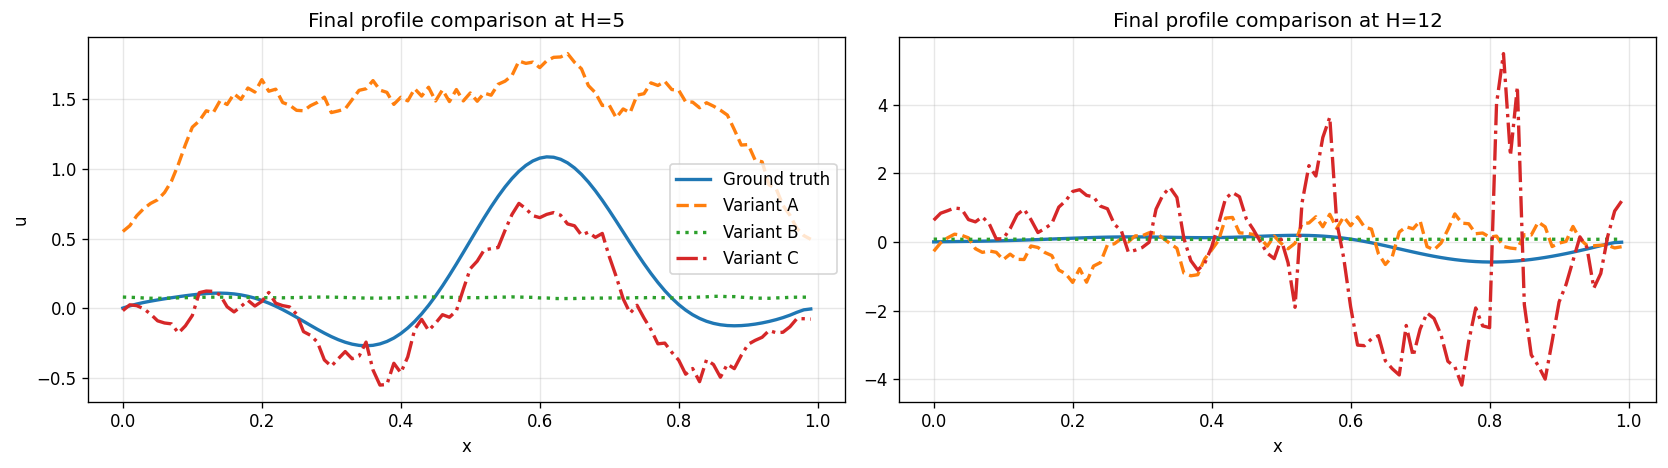

In [89]:
# 19) Single-trajectory rollout comparison across horizons H=5 and H=12 (Variants A/B/C)
# Native rolled axis: chunk index k (trajectory window steps), not chunk-internal time.
# Control alignment rule: use ctrl_seq[:, k] with current state u_k to predict u_{k+1}.

if "multistep_finetune_logs" not in globals():
    raise ValueError("Run section #14 first to produce `multistep_finetune_logs`.")

sample_id_cmp = 0
start_chunk_cmp = 0
horizons_cmp = [5, 12]

traj_sol_cmp = sol_test_chunks[sample_id_cmp]  # (n_chunks, chunk_len, nx, 1)
traj_ctrl_cmp = ctrl_test_chunks[sample_id_cmp]  # (n_chunks, chunk_len, n_ctrl, 1)

if traj_sol_cmp.shape[0] != traj_ctrl_cmp.shape[0]:
    raise ValueError(
        f"State/control chunk count mismatch: sol={traj_sol_cmp.shape[0]}, ctrl={traj_ctrl_cmp.shape[0]}"
    )

chunk_len_cmp = int(traj_sol_cmp.shape[1])
nx_cmp = int(traj_sol_cmp.shape[2])
n_ctrl_cmp = int(traj_ctrl_cmp.shape[2])

print("variant:", "sin_embed")
print("context:", "post-multistep-finetune")
print("traj_sol:", tuple(traj_sol_cmp.shape))
print("traj_ctrl:", tuple(traj_ctrl_cmp.shape))
print("n_intervals:", n_intervals)
print("chunk_len:", chunk_len_cmp, "nx:", nx_cmp, "n_ctrl:", n_ctrl_cmp)

model.eval()
ar_model.eval()

rows = []
plot_payload = {}

with torch.no_grad():
    for H_cmp in horizons_cmp:
        max_start_cmp = traj_sol_cmp.shape[0] - n_intervals - H_cmp
        if max_start_cmp < 0:
            raise ValueError(
                f"Not enough chunks for H={H_cmp}. Have n_chunks={traj_sol_cmp.shape[0]}, n_intervals={n_intervals}."
            )

        start_cmp = min(start_chunk_cmp, max_start_cmp)

        # History windows for warm-up Variant C.
        state_hist_chunks = traj_sol_cmp[
            start_cmp : start_cmp + n_intervals
        ]  # (T_hist, chunk_len, nx, 1)
        ctrl_hist_chunks = traj_ctrl_cmp[
            start_cmp : start_cmp + n_intervals
        ]  # (T_hist, chunk_len, n_ctrl, 1)

        x_state_hist_cmp = (
            state_hist_chunks.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
        )  # (1, T_hist, 1, chunk_len, nx)
        x_ctrl_hist_cmp = (
            ctrl_hist_chunks.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
        )  # (1, T_hist, 1, chunk_len, n_ctrl)

        u0_cmp = x_state_hist_cmp[:, -1]  # (1, 1, chunk_len, nx)

        ctrl_seq_chunks = traj_ctrl_cmp[
            start_cmp + n_intervals - 1 : start_cmp + n_intervals - 1 + H_cmp
        ]  # (H, chunk_len, n_ctrl, 1)
        ctrl_seq_cmp = (
            ctrl_seq_chunks.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
        )  # (1, H, 1, chunk_len, n_ctrl)

        y_true_chunks = traj_sol_cmp[
            start_cmp + n_intervals : start_cmp + n_intervals + H_cmp
        ]  # (H, chunk_len, nx, 1)

        assert x_state_hist_cmp.ndim == 5, x_state_hist_cmp.shape
        assert x_ctrl_hist_cmp.ndim == 5, x_ctrl_hist_cmp.shape
        assert ctrl_seq_cmp.ndim == 5, ctrl_seq_cmp.shape
        assert ctrl_seq_cmp.shape[1] == H_cmp, (ctrl_seq_cmp.shape, H_cmp)

        # Variant A: carry hidden states.
        pred_roll_A_cmp, _ = rollout_variant_a_carry(
            ar_model_obj=ar_model,
            u0=u0_cmp,
            ctrl_seq=ctrl_seq_cmp,
            steps=H_cmp,
        )  # (1, H+1, 1, chunk_len, nx)
        # Consistency check against wrapper rollout.
        pred_roll_A_cmp_ref = ar_model.rollout(
            u0=u0_cmp,
            ctrl_seq=ctrl_seq_cmp,
            steps=H_cmp,
        )
        assert torch.allclose(
            pred_roll_A_cmp, pred_roll_A_cmp_ref, atol=1e-6, rtol=1e-5
        ), f"Variant A helper mismatch vs ar_model.rollout for H={H_cmp}"

        # Variant B: reset hidden states at each step.
        pred_roll_B_cmp = rollout_variant_b_reset_each_step(
            ar_model_obj=ar_model,
            u0=u0_cmp,
            ctrl_seq=ctrl_seq_cmp,
            steps=H_cmp,
        )  # (1, H+1, 1, chunk_len, nx)

        # Variant C: warm-up on history then carry hidden states.
        pred_roll_C_cmp, warmup_steps_cmp, _ = rollout_variant_c_warmup_then_carry(
            ar_model_obj=ar_model,
            x_state_hist=x_state_hist_cmp,
            x_ctrl_hist=x_ctrl_hist_cmp,
            u0=u0_cmp,
            ctrl_seq=ctrl_seq_cmp,
            steps=H_cmp,
        )  # (1, H+1, 1, chunk_len, nx)

        assert torch.isfinite(pred_roll_A_cmp).all(), (
            f"Variant A non-finite for H={H_cmp}"
        )
        assert torch.isfinite(pred_roll_B_cmp).all(), (
            f"Variant B non-finite for H={H_cmp}"
        )
        assert torch.isfinite(pred_roll_C_cmp).all(), (
            f"Variant C non-finite for H={H_cmp}"
        )

        pred_chunks_A = (
            pred_roll_A_cmp[0, 1:].permute(0, 2, 3, 1).detach().cpu()
        )  # (H, chunk_len, nx, 1)
        pred_chunks_B = (
            pred_roll_B_cmp[0, 1:].permute(0, 2, 3, 1).detach().cpu()
        )  # (H, chunk_len, nx, 1)
        pred_chunks_C = (
            pred_roll_C_cmp[0, 1:].permute(0, 2, 3, 1).detach().cpu()
        )  # (H, chunk_len, nx, 1)
        true_chunks = y_true_chunks.detach().cpu()  # (H, chunk_len, nx, 1)

        assert pred_chunks_A.shape == true_chunks.shape
        assert pred_chunks_B.shape == true_chunks.shape
        assert pred_chunks_C.shape == true_chunks.shape

        # Full rollout metrics (all H*chunk_len points).
        pred_flat_A = pred_chunks_A.squeeze(-1).reshape(H_cmp * chunk_len_cmp, nx_cmp)
        pred_flat_B = pred_chunks_B.squeeze(-1).reshape(H_cmp * chunk_len_cmp, nx_cmp)
        pred_flat_C = pred_chunks_C.squeeze(-1).reshape(H_cmp * chunk_len_cmp, nx_cmp)
        true_flat = true_chunks.squeeze(-1).reshape(H_cmp * chunk_len_cmp, nx_cmp)

        mse_A = torch.mean((pred_flat_A - true_flat) ** 2).item()
        mse_B = torch.mean((pred_flat_B - true_flat) ** 2).item()
        mse_C = torch.mean((pred_flat_C - true_flat) ** 2).item()

        rel_A = (
            torch.linalg.norm(pred_flat_A - true_flat)
            / (torch.linalg.norm(true_flat) + 1e-12)
        ).item()
        rel_B = (
            torch.linalg.norm(pred_flat_B - true_flat)
            / (torch.linalg.norm(true_flat) + 1e-12)
        ).item()
        rel_C = (
            torch.linalg.norm(pred_flat_C - true_flat)
            / (torch.linalg.norm(true_flat) + 1e-12)
        ).item()

        # Endpoint metrics at step H.
        y_end_A = pred_roll_A_cmp[:, -1]  # (1, 1, chunk_len, nx)
        y_end_B = pred_roll_B_cmp[:, -1]  # (1, 1, chunk_len, nx)
        y_end_C = pred_roll_C_cmp[:, -1]  # (1, 1, chunk_len, nx)
        y_end_true = (
            y_true_chunks[-1].permute(2, 0, 1).unsqueeze(0).to(y_end_A.device).float()
        )  # (1, 1, chunk_len, nx)

        end_rel_A = (
            (
                torch.linalg.norm((y_end_A - y_end_true).reshape(1, -1), dim=1)
                / (torch.linalg.norm(y_end_true.reshape(1, -1), dim=1) + 1e-12)
            )
            .mean()
            .item()
        )
        end_rel_B = (
            (
                torch.linalg.norm((y_end_B - y_end_true).reshape(1, -1), dim=1)
                / (torch.linalg.norm(y_end_true.reshape(1, -1), dim=1) + 1e-12)
            )
            .mean()
            .item()
        )
        end_rel_C = (
            (
                torch.linalg.norm((y_end_C - y_end_true).reshape(1, -1), dim=1)
                / (torch.linalg.norm(y_end_true.reshape(1, -1), dim=1) + 1e-12)
            )
            .mean()
            .item()
        )

        rows.append(
            {
                "H": H_cmp,
                "warmup_steps": int(warmup_steps_cmp),
                "mse_A": mse_A,
                "mse_B": mse_B,
                "mse_C": mse_C,
                "rel_A": rel_A,
                "rel_B": rel_B,
                "rel_C": rel_C,
                "end_rel_A": end_rel_A,
                "end_rel_B": end_rel_B,
                "end_rel_C": end_rel_C,
                "shape_pred_roll": tuple(pred_roll_A_cmp.shape),
                "shape_true": tuple(true_chunks.shape),
            }
        )

        plot_payload[H_cmp] = {
            "x": x_cord.squeeze().cpu().numpy(),
            "true_final": true_flat[-1].numpy(),
            "pred_final_A": pred_flat_A[-1].numpy(),
            "pred_final_B": pred_flat_B[-1].numpy(),
            "pred_final_C": pred_flat_C[-1].numpy(),
        }

print("Rollout comparison summary (single trajectory):")
print("H | warmup | rollout_shape | true_shape")
for r in rows:
    print(
        f"{r['H']:>2d} | {r['warmup_steps']:>6d} | {r['shape_pred_roll']} | {r['shape_true']}"
    )

print("Relative L2 over full rollout (all predicted chunks):")
for r in rows:
    print(
        f"H={r['H']:>2d} | A={r['rel_A']:.6e} | B={r['rel_B']:.6e} | C={r['rel_C']:.6e} "
        # f"| (B-A)={r['rel_B'] - r['rel_A']:+.3e} | (C-A)={r['rel_C'] - r['rel_A']:+.3e} | (C-B)={r['rel_C'] - r['rel_B']:+.3e}"
    )

print("Endpoint Relative L2 at final step (k=H):")
for r in rows:
    print(
        f"H={r['H']:>2d} | A={r['end_rel_A']:.6e} | B={r['end_rel_B']:.6e} | C={r['end_rel_C']:.6e} "
        # f"| (B-A)={r['end_rel_B'] - r['end_rel_A']:+.3e} | (C-A)={r['end_rel_C'] - r['end_rel_A']:+.3e} | (C-B)={r['end_rel_C'] - r['end_rel_B']:+.3e}"
    )

# Final-profile overlays (one panel per horizon).
fig, axes = plt.subplots(
    1, len(horizons_cmp), figsize=(7 * len(horizons_cmp), 4), dpi=120
)
if len(horizons_cmp) == 1:
    axes = [axes]

for ax, H_cmp in zip(axes, horizons_cmp):
    pp = plot_payload[H_cmp]
    ax.plot(
        pp["x"], pp["true_final"], label="Ground truth", color="#1f77b4", linewidth=2
    )
    ax.plot(
        pp["x"],
        pp["pred_final_A"],
        label="Variant A",
        color="#ff7f0e",
        linestyle="--",
        linewidth=2,
    )
    ax.plot(
        pp["x"],
        pp["pred_final_B"],
        label="Variant B",
        color="#2ca02c",
        linestyle=":",
        linewidth=2,
    )
    ax.plot(
        pp["x"],
        pp["pred_final_C"],
        label="Variant C",
        color="#d62728",
        linestyle="-.",
        linewidth=2,
    )
    ax.set_title(f"Final profile comparison at H={H_cmp}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("u")
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()
